<a href="https://colab.research.google.com/github/oj3v0ns/MMM/blob/main/MMM_trainer_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##To work through

Budget allocation
* https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_budget_allocation_example.html
* https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_allocation_assessment.html
* https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_multi_objective_optimization.html
* https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_var_budget_optimization.html

Calibration
* https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_lift_test.html
* https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_geolift_calibration.html
* https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_roas_calibration.html

TVPs
* https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_tvp_example.html
* https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_time_varying_media_example.html


Long-term & funnel effects
* https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_funnel_mueffect.html
* https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_intro_upper_funnel.html
* https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_upper_funnel_causal_approach.html
* https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_brand_metrics_long_term.html



Then
* Revisit https://docs.google.com/presentation/d/1WGdhjEPYp4Yov_E06RklD4ohtYRbpyeIL_5_H2aER84/edit?slide=id.g37abf761792_0_31#slide=id.g37abf761792_0_31
* 8x experiment techniques

#Setup

##Packages & data

In [1]:
#import packages

import warnings

!pip install pymc-marketing pymc-extras

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
from pymc_extras.prior import Prior
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.metrics import r2_score

from pymc_marketing.mmm import LogisticSaturation
from pymc_marketing.mmm.multidimensional import MMM
from pymc_marketing.mmm.transformers import geometric_adstock, logistic_saturation

from pymc_marketing.mmm import (
    BinomialAdstock,
    DelayedAdstock,
    GeometricAdstock,
    WeibullCDFAdstock,
    WeibullPDFAdstock,
)
from pymc_marketing.mmm.transformers import (
    WeibullType,
    binomial_adstock,
    delayed_adstock,
    geometric_adstock,
    weibull_adstock,
)

from pymc_marketing.mmm.evaluation import (
    calculate_metric_distributions,
    compute_summary_metrics,
    summarize_metric_distributions,
)

import pytensor.xtensor as ptx

warnings.filterwarnings("ignore", category=FutureWarning)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

seed: int = sum(map(ord, "mmm"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

CB_COLORS = sns.color_palette("colorblind")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 720.1/720.1 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.9/331.9 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.1/253.1 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.1/41.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 521.1/521.1 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 600.5/600.5 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9

/tmp/ipykernel_584/2102045181.py:19: FutureWarning: `pymc_marketing.mmm.multidimensional` is deprecated and will be removed in a future release. Import from `pymc_marketing.mmm.mmm` (or directly from `pymc_marketing.mmm`) instead. The class `MultiDimensionalBudgetOptimizerWrapper` has been renamed to `BudgetOptimizerWrapper`; the old name is still available from this module as a temporary alias.
  from pymc_marketing.mmm.multidimensional import MMM


In [2]:
#load data from github

excel_url = "https://github.com/oj3v0ns/MMM/raw/8a73fc2d8d55fa3b285e169d7dee8aa7211278b7/Project%20Input%20Data%20with%20Spend.xlsx"
data = pd.read_excel(excel_url, sheet_name=0)

# convert date and y variable names to something more universal
data = data.rename(columns={"Accounts Subscriptions": "y"})
data = data.rename(columns={"Date": "date"})

# trend feature
n = data.shape[0]
data["t"] = range(n)

data.head()


,date,y,Google Display Cost,Google Branded Paid Search Cost,TV Cost,Google Generic Paid Search Cost,Influencers Cost,Meta Cost,YouTube Cost,Dates_School_Holidays,Competitors Promotion,Promotion,t
0,2022-01-01,4182.0,5.293500,3580.52,0.000000,5322.2000,0.0,11637.1932,5572.056,0,14.0,14.0,0
1,2022-01-08,5167.5,93.744731,5089.80,0.000000,8332.1816,2094.0,9171.1386,5466.384,6,14.0,14.0,1
2,2022-01-15,6229.0,1.553699,6805.89,6308.571429,11375.9528,1059.0,8847.9300,13711.656,7,14.0,14.0,2
3,2022-01-22,7801.5,240.301070,8085.96,44160.000000,10568.9024,174.0,8113.6578,16921.800,7,14.0,14.0,3
4,2022-01-29,9505.0,1.175135,7761.05,44160.000000,10806.5400,264.0,11027.9868,37302.216,7,14.0,14.0,4


## EDA

/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


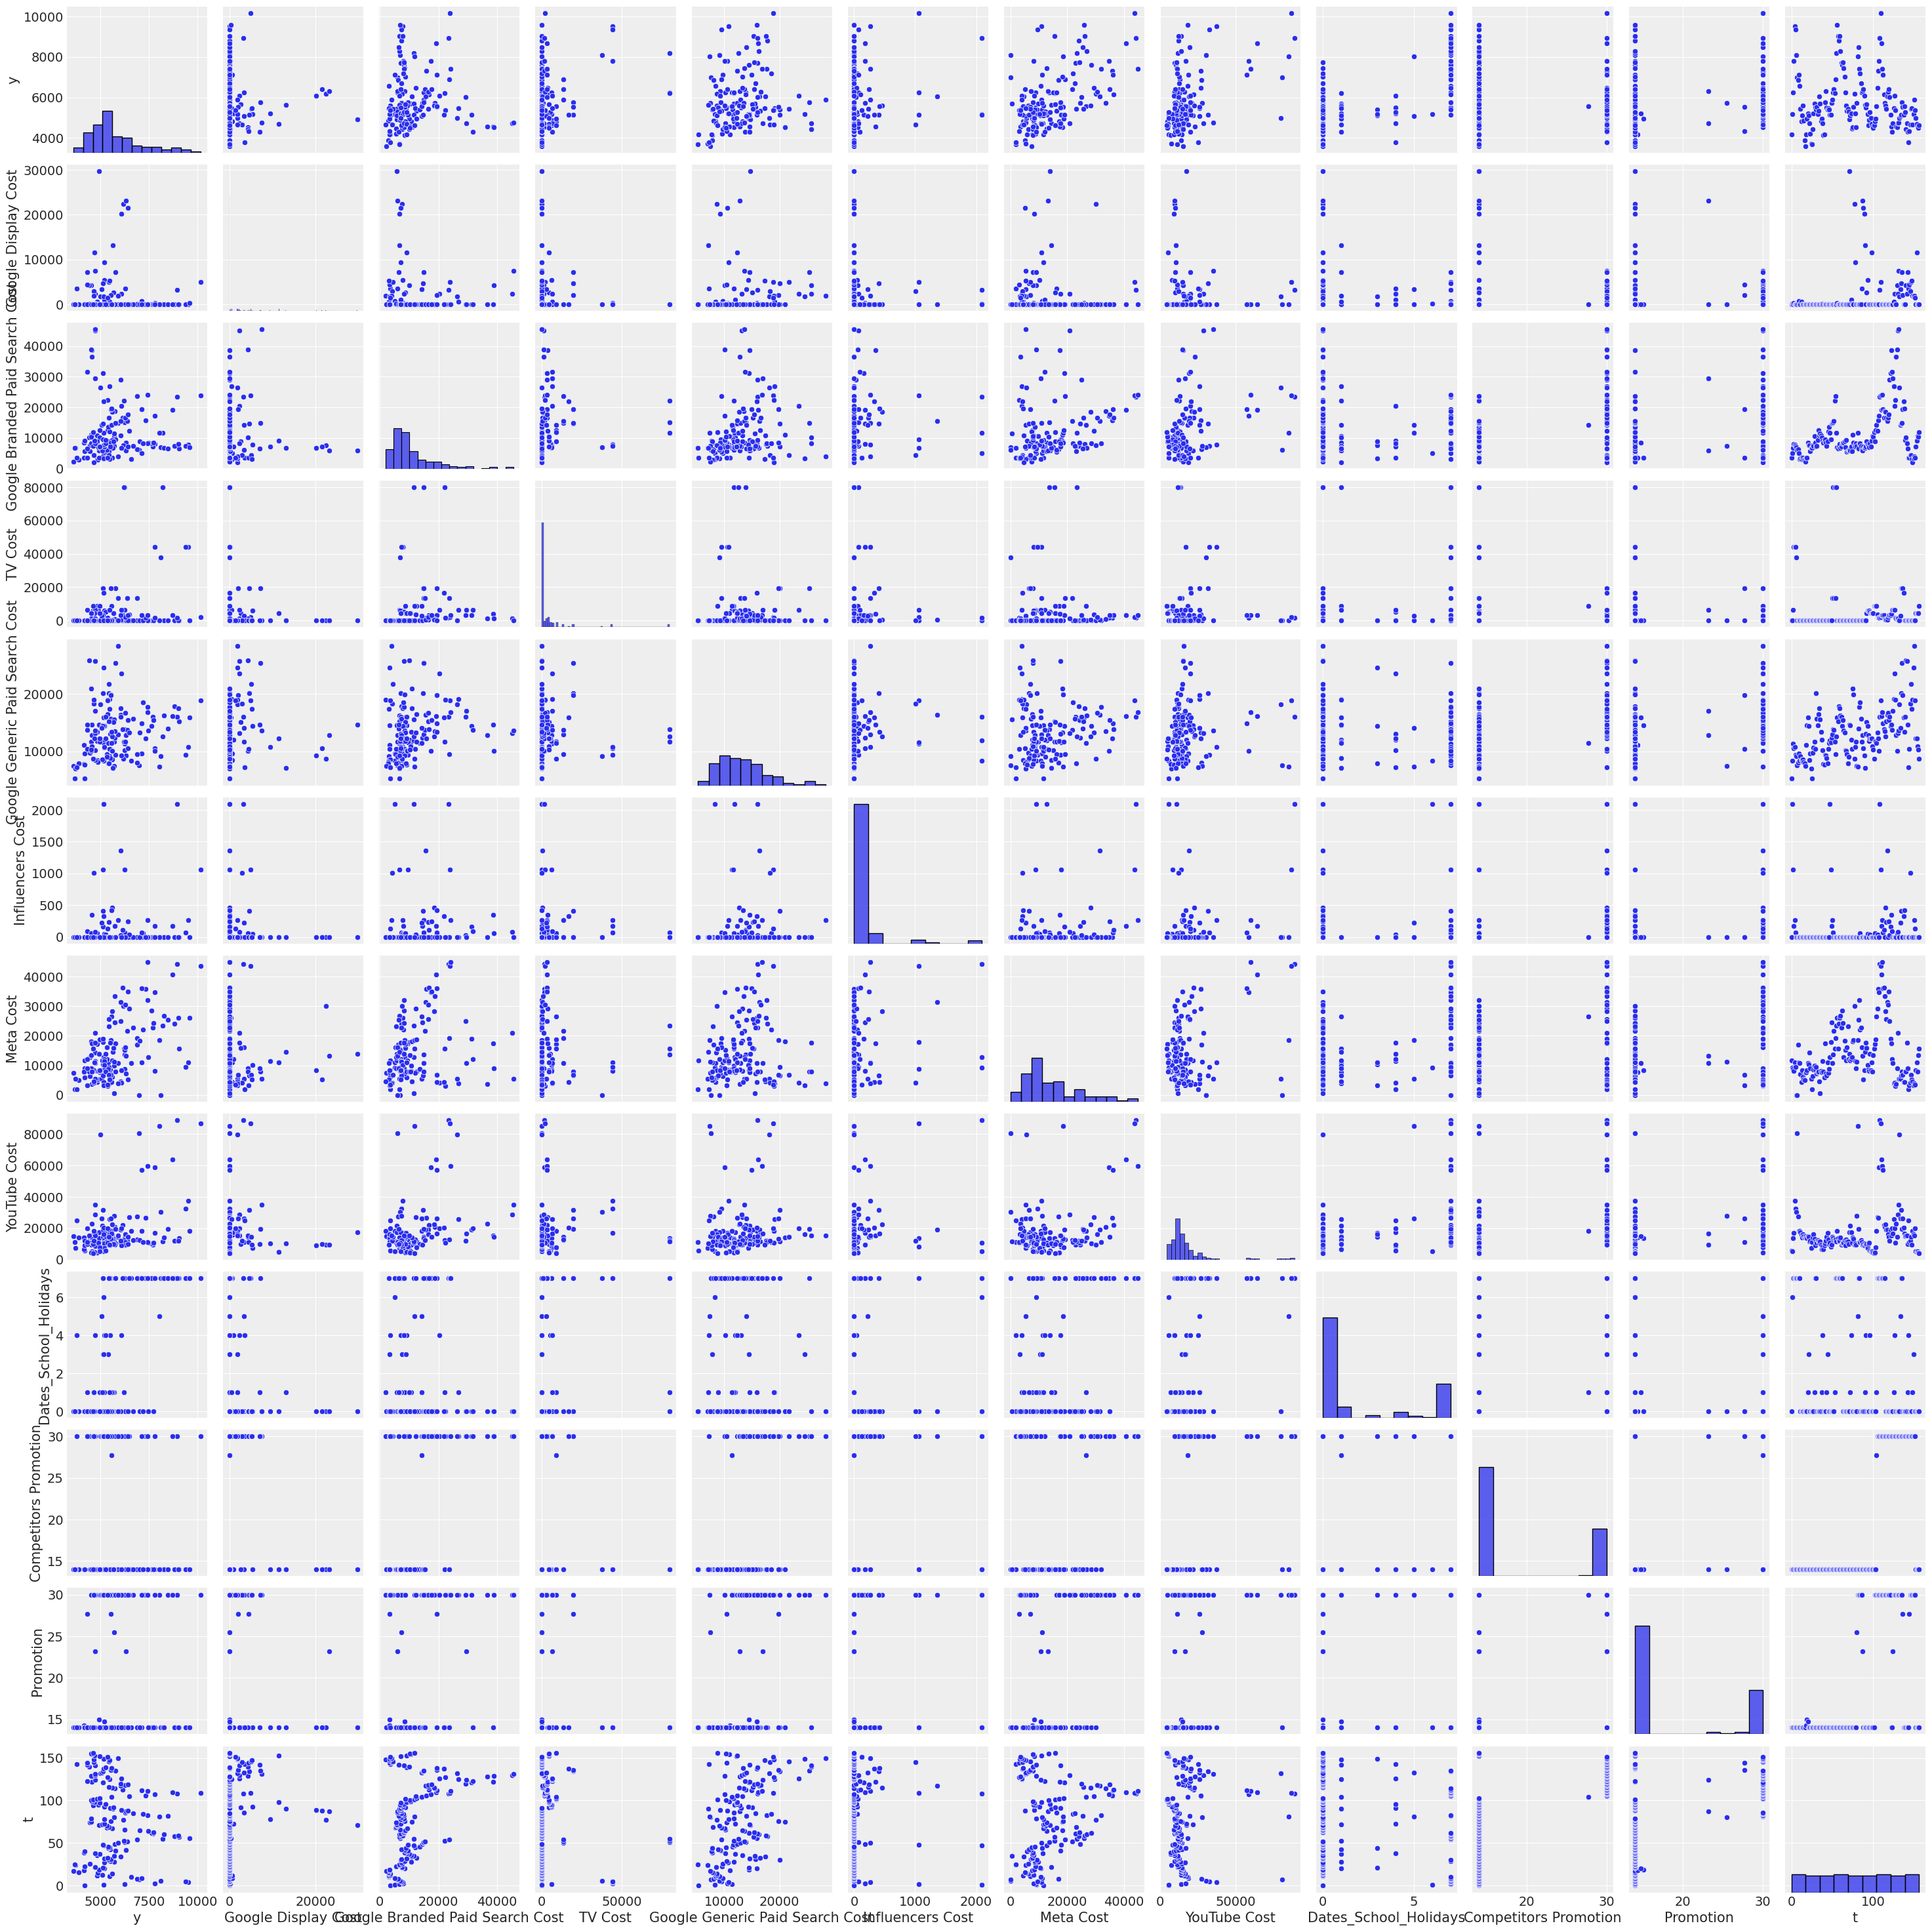

In [3]:
# Check scatterplots for a) relationship to sales, b) auto-correlation, c) linearity of relationships
# see https://www.kaggle.com/code/vinayplusj/marketing-mix-modelling#4.-Exploratory-Data-Analysis-(EDA)

sns.pairplot(data)
plt.show()

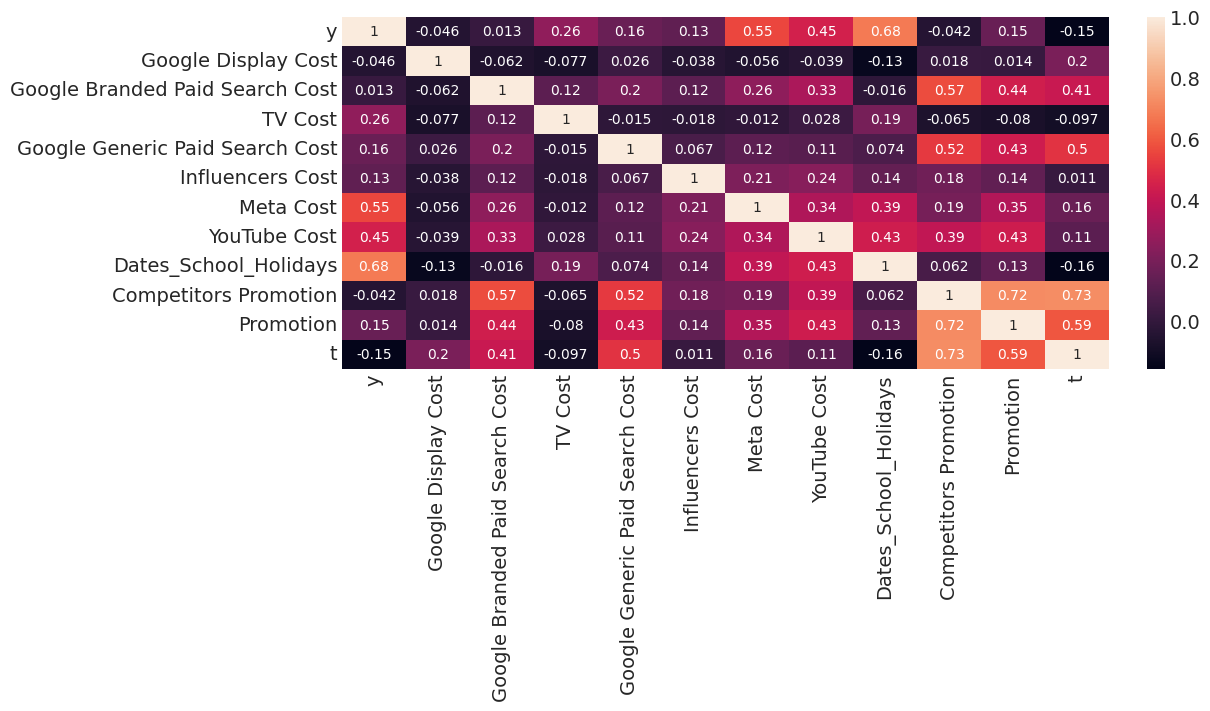

In [4]:
# correlation heatmap - check for auto/correlation and positive/ negative relationships

data_variables = data.loc[:, data.columns != 'date']
# Calculate the correlation matrix to examine relationships between numerical variables
corr = data_variables.corr()
# Visualize the correlation matrix using a heatmap for better interpretability
sns.heatmap(corr, annot=True)
# Display the heatmap
plt.show()

##Define variables

In [5]:
#for scikit learn convention

X = data.drop("y", axis=1)
y = data["y"]

In [6]:
# Define the split point for train and test sets

n_test_weeks = 5
split_point = len(data) - n_test_weeks

# Create training and test dataframes
data_train = data.iloc[:split_point]
data_test = data.iloc[split_point:]

# Define X and y for the training set
X_train = data_train.drop("y", axis=1)
y_train = data_train["y"]

# Define X and y for the test set
X_test = data_test.drop("y", axis=1)
y_test = data_test["y"]

print(f"Training data shape: {data_train.shape}")
print(f"Test data shape: {data_test.shape}")

Training data shape: (152, 13)
Test data shape: (5, 13)


In [7]:
# define channels and controls for convenience

channels = [
    "Google Display Cost",
    "Meta Cost",
    "Google Generic Paid Search Cost",
    "TV Cost",
    "Influencers Cost",
    "Google Branded Paid Search Cost",
    "YouTube Cost",
]

controls = [
    "Dates_School_Holidays",
    "Competitors Promotion",
    "Promotion",
    "t",
]

##Define priors

In [8]:
# view dummy model

dummy_model = MMM(
    date_column="",
    channel_columns=[""],
    adstock=GeometricAdstock(l_max=4),
    saturation=LogisticSaturation(),
)
dummy_model.default_model_config

{'intercept': Prior("Normal", mu=0, sigma=2, dims=()),
 'likelihood': Prior("Normal", sigma=Prior("HalfNormal", sigma=2, dims=()), dims="date"),
 'gamma_control': Prior("Normal", mu=0, sigma=2, dims="control"),
 'gamma_fourier': Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
 'adstock_alpha': Prior("Beta", alpha=1, beta=3, dims="channel"),
 'saturation_lam': Prior("Gamma", alpha=3, beta=1, dims="channel"),
 'saturation_beta': Prior("HalfNormal", sigma=2, dims="channel")}

### Saturation

In [9]:
# view default saturation priors
saturation = LogisticSaturation()
saturation.default_priors

{'lam': Prior("Gamma", alpha=3, beta=1), 'beta': Prior("HalfNormal", sigma=2)}

Higher
𝛽
 → Higher beta maximum contribution (the curve’s ceiling)

Higher lambda
𝜆
 → Faster saturation (the curve rises more steeply but plateaus sooner)

 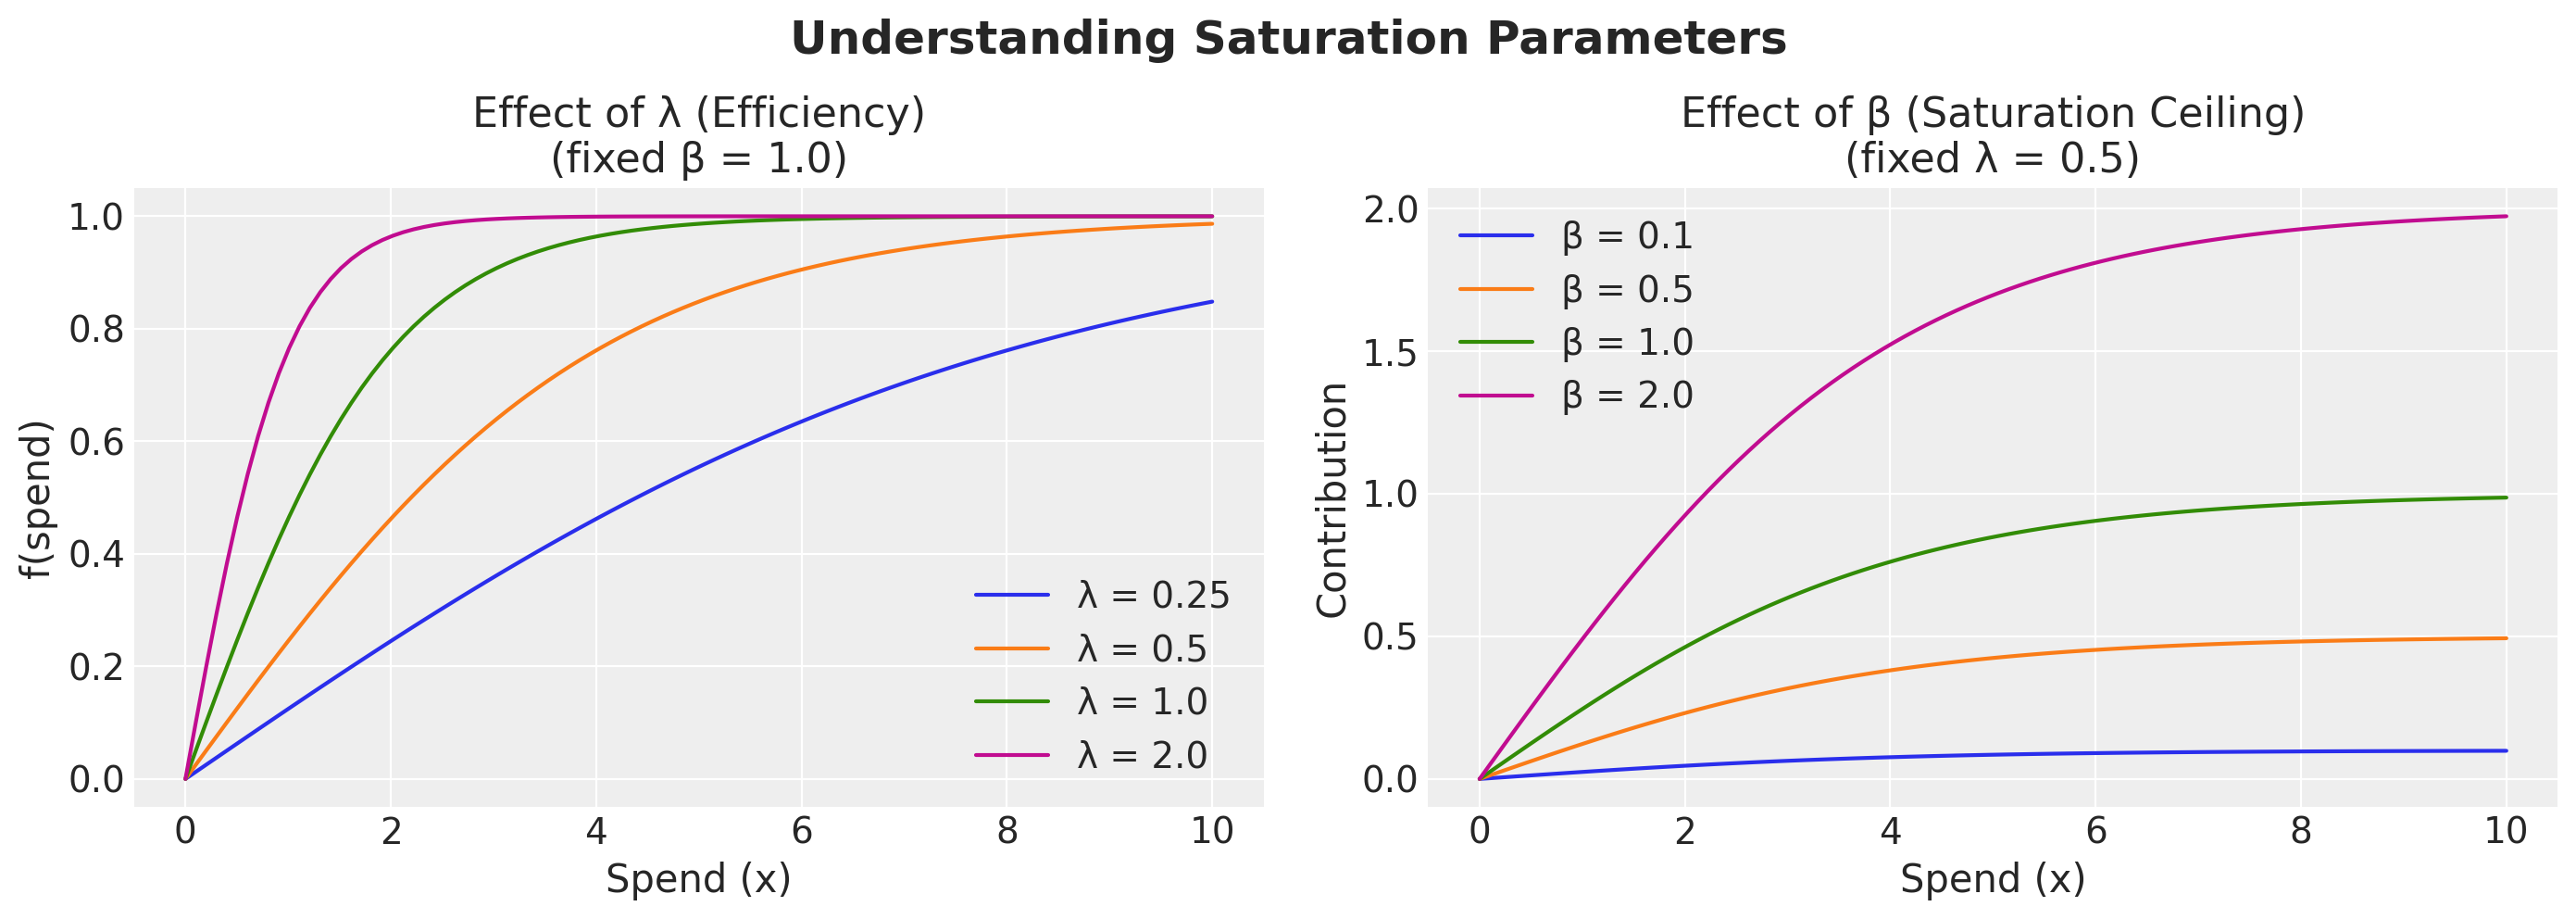

Output()

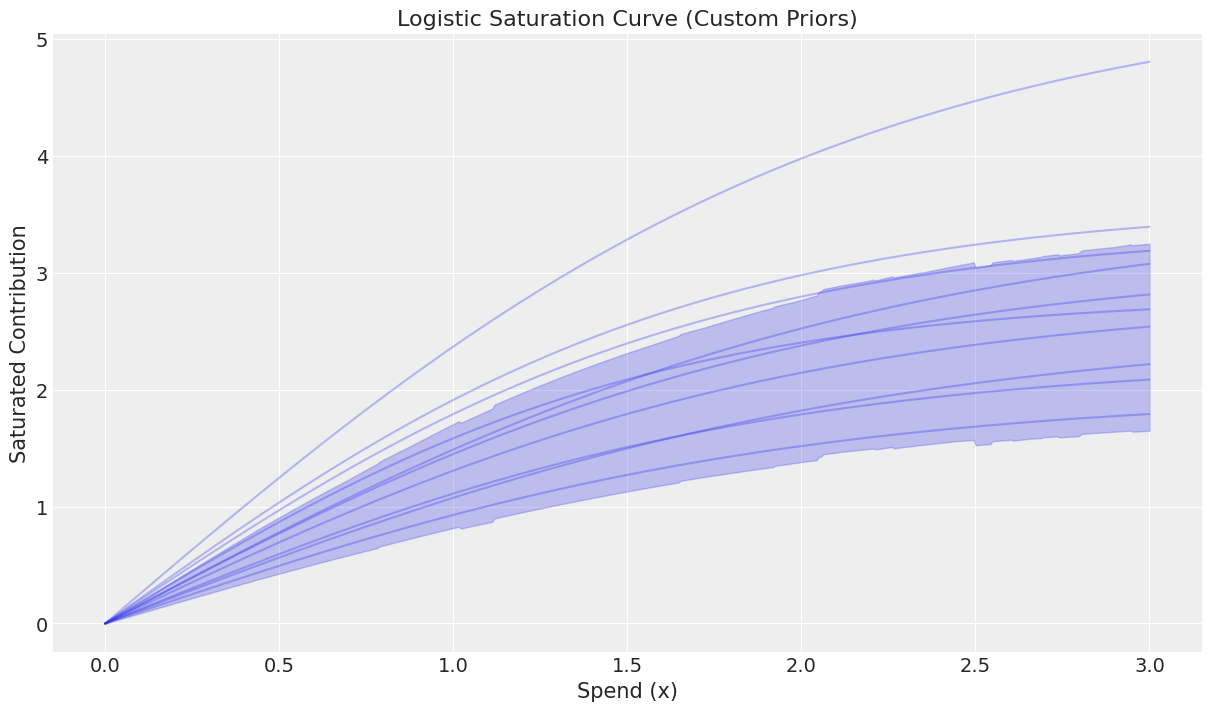

In [10]:
# Test a LogisticSaturation instance with different priors - add to model config
saturation = LogisticSaturation(
    {
        "lam": Prior("Gamma", alpha=100, beta=100),
        "beta": Prior("LogNormal", mu=1, sigma=0.2),
    }
)

# Sample from the prior distributions
prior = saturation.sample_prior(random_seed=rng)

# Sample the saturation curve across a range of spend values
curve = saturation.sample_curve(prior, num_points=500, max_value=3)

# Plot the saturation curve with uncertainty (HDI and samples)
fig, axes = saturation.plot_curve(curve, random_seed=rng)
axes[0].set(
    xlabel="Spend (x)",
    ylabel="Saturated Contribution",
    title="Logistic Saturation Curve (Custom Priors)",
);

In [11]:
# compute share of spend as a starting point for media priors

total_spend_per_channel = data[channels].sum(axis=0)
spend_share = total_spend_per_channel / total_spend_per_channel.sum()

n_channels = 7

prior_sigma = n_channels * spend_share.to_numpy()
prior_sigma.tolist()

[0.18836945547545192,
 1.5739825150186304,
 1.4777468876979822,
 0.5101934237645955,
 0.012253444879202584,
 1.273920697506585,
 1.963533575657552]

### Adstock

https://www.pymc-marketing.io/en/stable/notebooks/mmm/adstock_functions_guide.html#comparison-across-all-adstock-functions

/tmp/ipykernel_584/4263372392.py:109: UserWarning: The figure layout has changed to tight
  plt.tight_layout()



Key Differences:
- Geometric (blue): Immediate peak, exponential decay
- Delayed (orange): Peak shifted forward in time
- Weibull CDF (purple): Gradual S-shaped buildup
- Weibull PDF (red): Peak after delay, then decay
- Binomial (green): Flexible decay shape


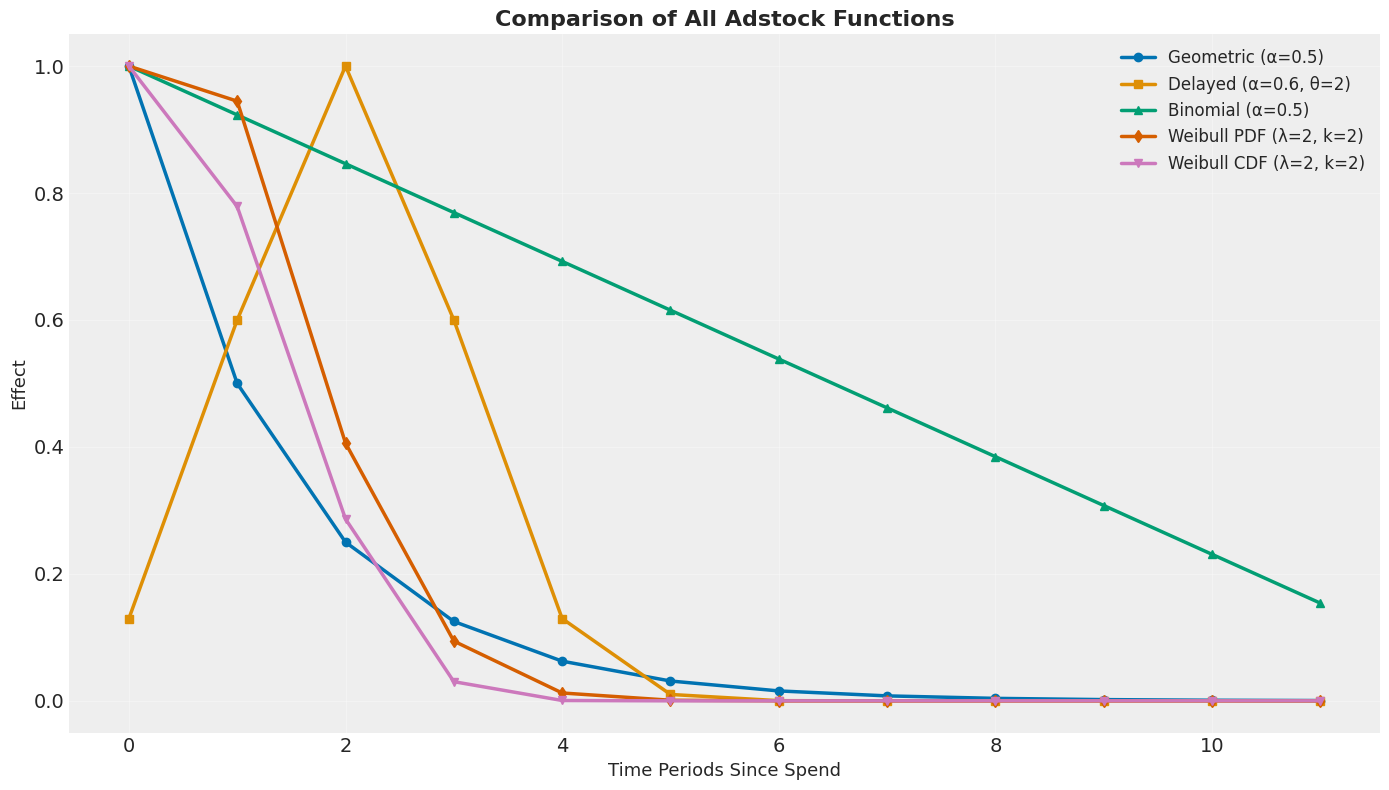

In [12]:
# Experiment with adstock types and forms, then integrate into model specification if needed

fig, ax = plt.subplots(figsize=(14, 8))

l_max = 12
impulse = np.zeros(l_max)
impulse[0] = 1.0

# Geometric
geo = geometric_adstock(
    ptx.as_xtensor(impulse, dims=("time",)),
    alpha=0.5,
    l_max=l_max,
    normalize=False,
    dim="time",
).eval()
ax.plot(
    range(l_max),
    geo,
    marker="o",
    linewidth=2.5,
    label="Geometric (α=0.5)",
    markersize=6,
    color=CB_COLORS[0],
)

# Delayed
delayed_result = delayed_adstock(
    ptx.as_xtensor(impulse, dims=("time",)),
    alpha=0.6,
    theta=2,
    l_max=l_max,
    normalize=False,
    dim="time",
).eval()
ax.plot(
    range(l_max),
    delayed_result,
    marker="s",
    linewidth=2.5,
    label="Delayed (α=0.6, θ=2)",
    markersize=6,
    color=CB_COLORS[1],
)

# Binomial
binom = binomial_adstock(
    ptx.as_xtensor(impulse, dims=("time",)),
    alpha=0.5,
    l_max=l_max,
    normalize=False,
    dim="time",
).eval()
ax.plot(
    range(l_max),
    binom,
    marker="^",
    linewidth=2.5,
    label="Binomial (α=0.5)",
    markersize=6,
    color=CB_COLORS[2],
)

# Weibull PDF
wpdf = weibull_adstock(
    ptx.as_xtensor(impulse, dims=("time",)),
    lam=2,
    k=2,
    l_max=l_max,
    type=WeibullType.PDF,
    normalize=False,
    dim="time",
).eval()
ax.plot(
    range(l_max),
    wpdf,
    marker="d",
    linewidth=2.5,
    label="Weibull PDF (λ=2, k=2)",
    markersize=6,
    color=CB_COLORS[3],
)

# Weibull CDF
wcdf = weibull_adstock(
    ptx.as_xtensor(impulse, dims=("time",)),
    lam=2,
    k=2,
    l_max=l_max,
    type=WeibullType.CDF,
    normalize=False,
    dim="time",
).eval()
ax.plot(
    range(l_max),
    wcdf,
    marker="v",
    linewidth=2.5,
    label="Weibull CDF (λ=2, k=2)",
    markersize=6,
    color=CB_COLORS[4],
)

ax.set_xlabel("Time Periods Since Spend", fontsize=13)
ax.set_ylabel("Effect", fontsize=13)
ax.set_title("Comparison of All Adstock Functions", fontsize=16, fontweight="bold")
ax.legend(fontsize=12, loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()

print("\nKey Differences:")
print("- Geometric (blue): Immediate peak, exponential decay")
print("- Delayed (orange): Peak shifted forward in time")
print("- Weibull CDF (purple): Gradual S-shaped buildup")
print("- Weibull PDF (red): Peak after delay, then decay")
print("- Binomial (green): Flexible decay shape")

### Other

In [13]:
# integrate media priors into your model configuration

my_model_config = {
    "intercept": Prior("Normal", mu=0.5, sigma=0.2),
    "saturation_beta": Prior("HalfNormal", sigma=prior_sigma, dims="channel"),
    "gamma_control": Prior("Normal", mu=0, sigma=0.05, dims="control"),
    "gamma_fourier": Prior("Laplace", mu=0, b=0.2, dims="fourier_mode"),
    "likelihood": Prior("Normal", sigma=Prior("HalfNormal", sigma=6)),
}

### Log models

... decompose using a counterfactual and not a direct split. This is because, in a multiplicative model, the components are added inside
𝜇
 but multiplied on the
𝑦
-scale (
𝑦 =∏𝑐exp⁡(𝑣𝑐)
). There is no additive term on the
𝑦
-scale to read off as “channel
𝑐
’s sales”, so the only honest way to attribute sales is to ask what
𝑦
 would have been without
𝑐
. **The counterfactual is exactly that question.**


**Because each component’s counterfactual absorbs its share of every interaction it participates in, per-component contributions overlap**: their sum exceeds
ˆ
𝑦
⁡(𝑡)
. This is a property of asking a per-component “what-if” question in a non-linear model, not a bug. **Each value is individually correct (“removing X costs this much”); they simply cannot be stacked into an exact pie chart.**

In a multiplicative (log-link) model the intercept enters as
𝑒𝛼
 and combines with media, controls, and seasonality through multiplication, not addition. There is no portion of
𝑦
 that the intercept “owns” the way it does in an additive model; **instead it sets the log-baseline against which every other component multiplies.** When the other components together already explain most of
𝑦
, the intercept’s posterior centres below zero (
𝛼 <0
), because
𝑒𝛼 <1
 is the multiplicative correction the model needs.

# Training model

## Model specification - train

In [14]:
my_sampler_config = {"progressbar": True}

/usr/local/lib/python3.13/dist-packages/pymc_extras/prior.py:851: UserWarning: Implicit conversion of array-like parameter sigma to DataArray with dims ('channel',). Use DataArray with explicit dims to avoid this warning
  return _param_value_with_dims(param, value, dims=self.dims)


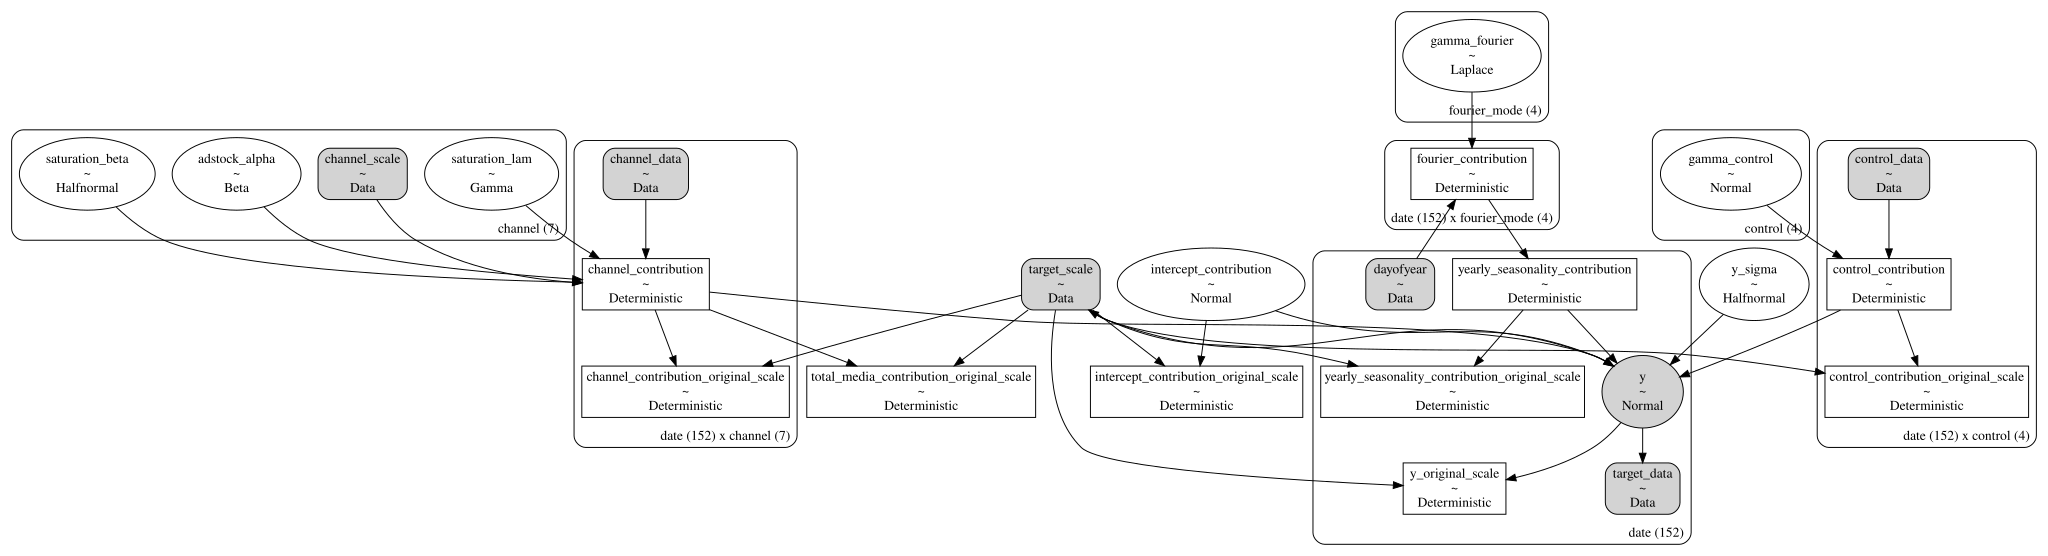

In [15]:
# specify the model based on your model configuration

mmm = MMM(
    model_config=my_model_config,
    sampler_config=my_sampler_config,
    date_column="date", # no need to change
    target_column="y", # no need to change
    adstock=GeometricAdstock(l_max=8), # change to specific adstock type/ config if required
    saturation=LogisticSaturation(), #change to 'saturation' if custom priors specified, "LogSaturation" if a Log-Log model is needed
    channel_columns=channels, # no need to change
    control_columns=controls, # no need to change
    yearly_seasonality=2,
    link="identity", #Components add to 𝑦 - change to "log" if components multiply to 𝑦
)

# Build the model and add contribution variables in original scale
mmm.build_model(X_train, y_train)
mmm.add_original_scale_contribution_variable(
    var=[
        "channel_contribution",
        "control_contribution",
        "intercept_contribution",
        "yearly_seasonality_contribution",
        "y",
    ]
)

pm.model_to_graphviz(mmm.model)

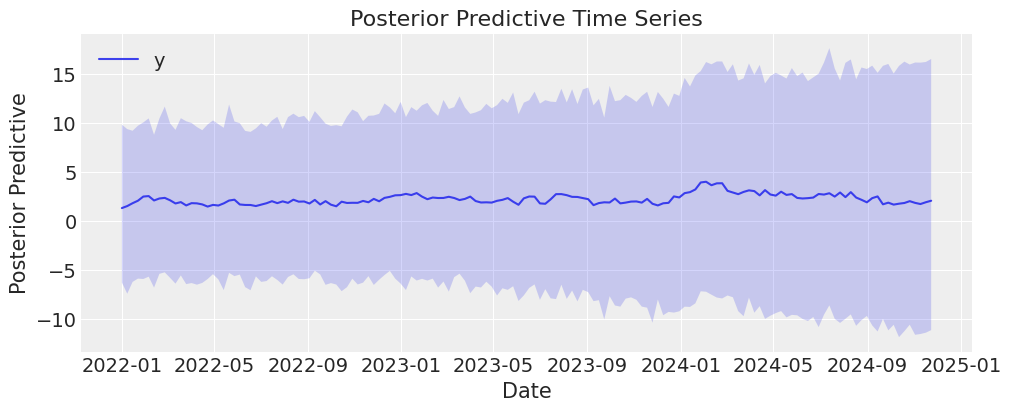

In [16]:
# Generate prior predictive samples

mmm.sample_prior_predictive(X_train, y_train, samples=2_000)
fig, axes = mmm.plot.prior_predictive()

AttributeError: module 'arviz' has no attribute 'plot_hdi'

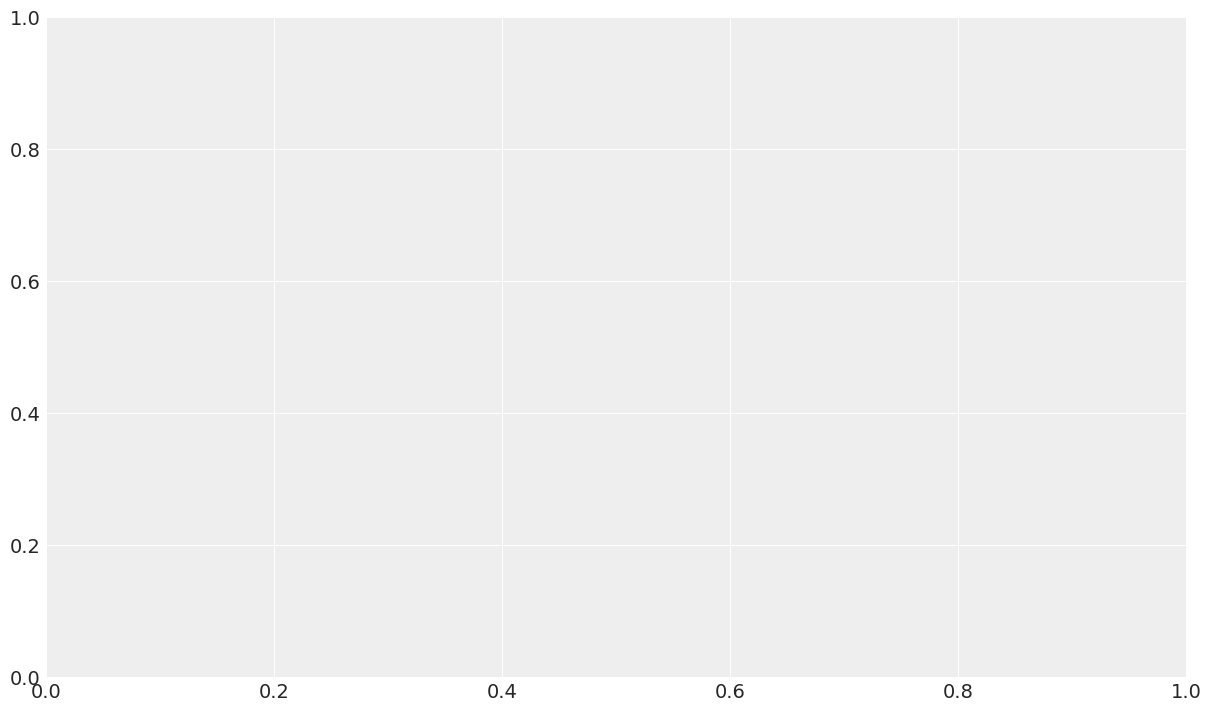

In [17]:
# Prior predictive checks in the original scale

fig, ax = plt.subplots()
for i, hdi_prob in enumerate([0.94, 0.5]):
    az.plot_hdi(
        x=mmm.model.coords["date"],
        y=mmm.idata["prior"]["y_original_scale"].unstack().transpose(..., "date"),
        smooth=False,
        color="C0",
        hdi_prob=hdi_prob,
        fill_kwargs={"alpha": 0.3 + i * 0.1, "label": f"{hdi_prob:.0%} HDI"},
        ax=ax,
    )
sns.lineplot(data=data, x="date", y="y", color="black", label="Observed", ax=ax)
ax.legend(loc="upper left")
ax.set(xlabel="date", ylabel="y")
ax.set_title("Prior Predictive Checks", fontsize=18, fontweight="bold");

## Model fitting - train

In [18]:
%%time

mmm.fit(
    X=X_train,
    y=y_train,
    chains=2, #change to 4 for accuracy
    tune=1_000, #change to 1_500 for accuracy
    draws=1_000,
    target_accept=0.85, #change to 0.9+ for accuracy
    random_seed=rng,
)

Output()

ERROR:pymc.stats.convergence:There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

CPU times: user 1min 40s, sys: 947 ms, total: 1min 41s
Wall time: 1min 46s


<xarray.DataTree>
Group: /
│   Attributes: (12/24)
│       id:                         22ddcf9d15bf5b88
│       model_type:                 MMMM (Multi-Dimensional Marketing Mix Model)
│       version:                    0.0.2
│       sampler_config:             {"progressbar": true}
│       model_config:               {"intercept": {"dist": "Normal", "kwargs": {"...
│       __serialization_version__:  1
│       ...                         ...
│       scaling:                    {"__type__": "pymc_marketing.mmm.scaling.Scal...
│       dag:                        null
│       treatment_nodes:            null
│       outcome_node:               null
│       mu_effects:                 []
│       cost_per_unit:              null
├── Group: /prior
│       Dimensions:                                         (chain: 1, draw: 2000,
│                                                            date: 152, control: 4,
│                                                            channel: 7, fourier_mode: 4)
│       Coordinates:
│         * chain                                           (chain) int64 8B 0
│         * draw                                            (draw) int64 16kB 0 ... 1999
│         * date                                            (date) datetime64[ns] 1kB ...
│         * control                                         (control) <U21 336B 'Date...
│         * channel                                         (channel) <U31 868B 'Goog...
│         * fourier_mode                                    (fourier_mode) <U5 80B 's...
│       Data variables: (12/17)
│           y_sigma                                         (chain, draw) float64 16kB ...
│           control_contribution_original_scale             (chain, draw, date, control) float64 10MB ...
│           intercept_contribution_original_scale           (chain, draw) float64 16kB ...
│           channel_contribution                            (chain, draw, date, channel) float64 17MB ...
│           gamma_control                                   (chain, draw, control) float64 64kB ...
│           control_contribution                            (chain, draw, date, control) float64 10MB ...
│           ...                                              ...
│           y_original_scale                                (chain, draw, date) float64 2MB ...
│           gamma_fourier                                   (chain, draw, fourier_mode) float64 64kB ...
│           saturation_beta                                 (chain, draw, channel) float64 112kB ...
│           yearly_seasonality_contribution                 (chain, draw, date) float64 2MB ...
│           channel_contribution_original_scale             (chain, draw, date, channel) float64 17MB ...
│           intercept_contribution                          (chain, draw) float64 16kB ...
│       Attributes:
│           created_at:                 2026-09-22T13:59:07.869350+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│           pymc_marketing_version:     1.1.0
├── Group: /prior_predictive
│       Dimensions:  (chain: 1, draw: 2000, date: 152)
│       Coordinates:
│         * chain    (chain) int64 8B 0
│         * draw     (draw) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
│         * date     (date) datetime64[ns] 1kB 2022-01-01 2022-01-08 ... 2024-11-23
│       Data variables:
│           y        (chain, draw, date) float64 2MB -6.796 0.7468 ... -6.746 -2.836
│       Attributes:
│           created_at:                 2026-09-22T13:59:07.878392+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_

In [ ]:
# save the model

mmm.save(fname="model_train")

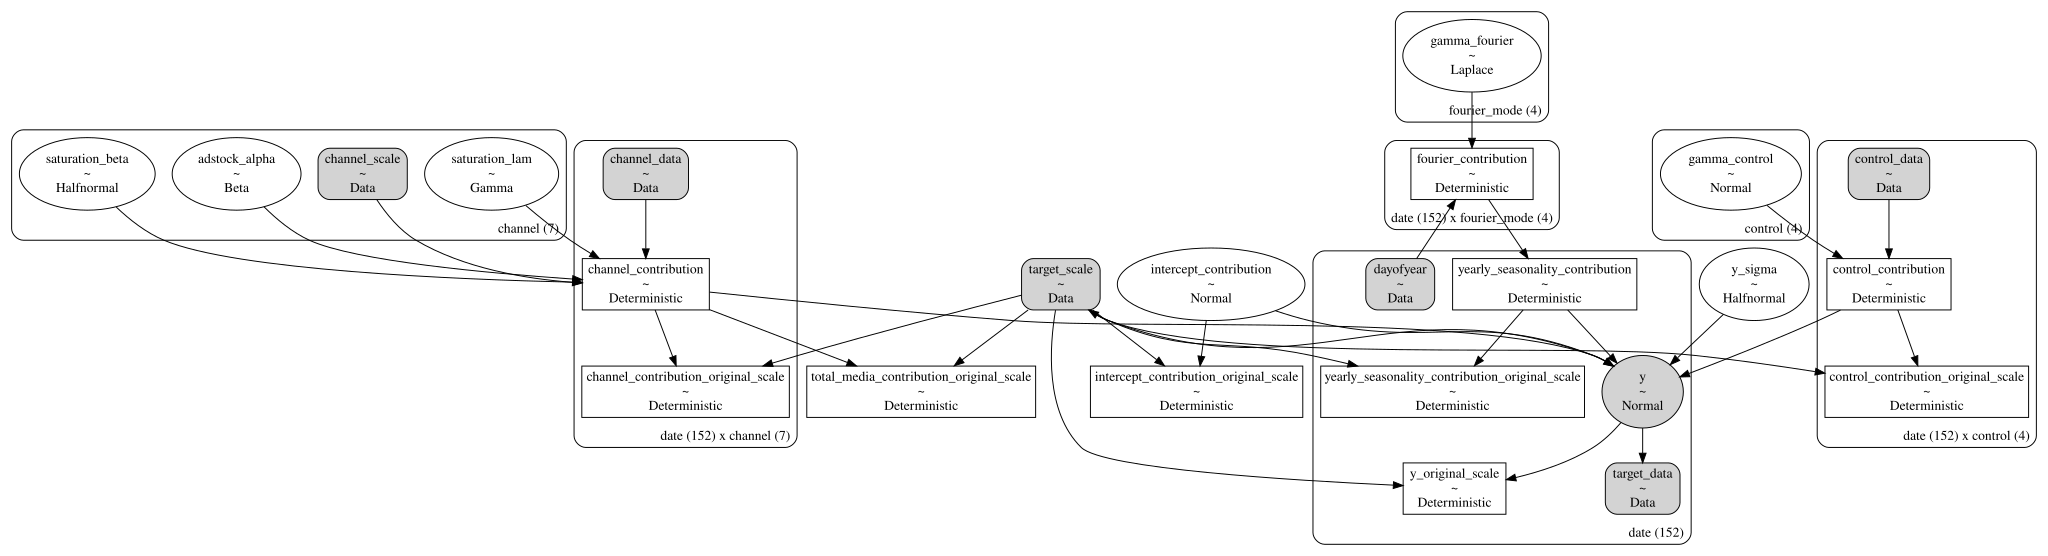

In [19]:
# view the model structure

mmm.graphviz()

In [ ]:
# load the model (if needed)

mmm.load(fname="model_train")

## Model diagnostics - train

In [20]:
mmm.table()

                                 Variable  Expression                                  Dimensions                  
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                          channel_scale =  Data                                        channel[7]                  
                           target_scale =  Data                                                                    
                           channel_data =  Data                                        date[152] × channel[7]      
                            target_data =  Data                                        date[152]                   
                           control_data =  Data                                        date[152] × control[4]      
                              dayofyear =  Data                                        date[152]                   
                                                                                                                   
                 intercept_contribution ~  Normal(0.5, 0.2)                                                        
                          adstock_alpha ~  Beta(1, 3)                                  channel[7]                  
                         saturation_lam ~  Gamma(3, <constant>)                        channel[7]                  
                        saturation_beta ~  HalfNormal(0, <constant>)                   channel[7]                  
                          gamma_control ~  Normal(0, 0.05)                             control[4]                  
                          gamma_fourier ~  Laplace(0, 0.2)                             fourier_mode[4]             
                                y_sigma ~  HalfNormal(0, 6)                                                        
                                                                                       Parameter count = 31        
                                                                                                                   
                   channel_contribution =  f(saturation_beta, saturation_lam,          date[152] × channel[7]      
                                           adstock_alpha)                                                          
                   control_contribution =  f(gamma_control)                            date[152] × control[4]      
                   fourier_contribution =  f(gamma_fourier)                            date[152] × fourier_mode[4] 
        yearly_seasonality_contribution =  f(gamma_fourier)                            date[152]                   
  total_media_contribution_original_scale  f(saturation_beta, saturation_lam,                                      
                                        =  adstock_alpha)                                                          
    channel_contribution_original_scale =  f(saturation_beta, saturation_lam,          date[152] × channel[7]      
                                           adstock_alpha)                                                          
    control_contribution_original_scale =  f(gamma_control)                            date[152] × control[4]      
  intercept_contribution_original_scale =  f(intercept_contribution)                                               
 yearly_seasonality_contribution_origina…  f(gamma_fourier)                            date[152]                   
                                        =                                                                          
                       y_original_scale =  f(y)                                        date[152]                   
                                                                                                                   
                                      y ~  Normal(f(intercept_contribution,            date[152]                   
                                           gamma_control

In [21]:
# Number of diverging samples

mmm.idata["sample_stats"]["diverging"].sum().item()

2

In [22]:
mmm.fit_result

<xarray.Dataset> Size: 71MB
Dimensions:                                         (chain: 2, draw: 1000,
                                                     fourier_mode: 4,
                                                     control: 4, channel: 7,
                                                     date: 152)
Coordinates:
  * chain                                           (chain) int64 16B 0 1
  * draw                                            (draw) int64 8kB 0 1 ... 999
  * fourier_mode                                    (fourier_mode) <U5 80B 's...
  * control                                         (control) <U21 336B 'Date...
  * channel                                         (channel) <U31 868B 'Goog...
  * date                                            (date) datetime64[ns] 1kB ...
Data variables: (12/17)
    y_sigma                                         (chain, draw) float64 16kB ...
    gamma_fourier                                   (chain, draw, fourier_mode) float64 64kB ...
    gamma_control                                   (chain, draw, control) float64 64kB ...
    adstock_alpha                                   (chain, draw, channel) float64 112kB ...
    saturation_lam                                  (chain, draw, channel) float64 112kB ...
    saturation_beta                                 (chain, draw, channel) float64 112kB ...
    ...                                              ...
    channel_contribution_original_scale             (chain, draw, date, channel) float64 17MB ...
    total_media_contribution_original_scale         (chain, draw) float64 16kB ...
    yearly_seasonality_contribution                 (chain, draw, date) float64 2MB ...
    fourier_contribution                            (chain, draw, date, fourier_mode) float64 10MB ...
    control_contribution                            (chain, draw, date, control) float64 10MB ...
    channel_contribution                            (chain, draw, date, channel) float64 17MB ...
Attributes:
    created_at:                 2026-09-22T14:00:58.182933+00:00
    creation_library:           ArviZ
    creation_library_version:   1.3.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  6.2.0
    sample_dims:                ['chain', 'draw']
    sampling_time:              70.30278301239014
    tuning_steps:               1000
    pymc_marketing_version:     1.1.0

In [23]:
# summary of the trace

az.summary(
    data=mmm.fit_result,
    var_names=[
        "adstock_alpha",
        "gamma_control",
        "gamma_fourier",
        "intercept_contribution",
        "saturation_beta",
        "saturation_lam",
        "y_sigma",
    ],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
adstock_alpha[Google Display Cost],0.202,0.166,0.015,0.52,2006,1103,1.00,0.0034,0.0043
adstock_alpha[Meta Cost],0.32,0.223,0.035,0.73,1437,1180,1.00,0.0057,0.0043
adstock_alpha[Google Generic Paid Search Cost],0.313,0.14,0.081,0.53,1374,902,1.00,0.0038,0.0034
adstock_alpha[TV Cost],0.49,0.231,0.07,0.81,1240,1043,1.00,0.0069,0.004
adstock_alpha[Influencers Cost],0.25,0.184,0.02,0.59,2512,1249,1.00,0.0033,0.0036
adstock_alpha[Google Branded Paid Search Cost],0.244,0.184,0.02,0.6,1642,1197,1.00,0.0042,0.0045
adstock_alpha[YouTube Cost],0.13,0.09,0.014,0.29,1672,965,1.00,0.0019,0.0019
gamma_control[Dates_School_Holidays],0.0095,0.0028,0.005,0.014,1351,1255,1.00,7.6e-05,6.2e-05
gamma_control[Competitors Promotion],-0.0096,0.00198,-0.013,-0.0064,1027,1239,1.00,6.2e-05,4.3e-05
gamma_control[Promotion],0.00301,0.00127,0.0009,0.005,1844,1418,1.00,3e-05,2.8e-05


In [24]:
# plot the trace - check for good chain mixing

_ = az.plot_trace(
    data=mmm.fit_result,
    var_names=[
        "adstock_alpha",
        "gamma_control",
        "gamma_fourier",
        "intercept_contribution",
        "saturation_beta",
        "saturation_lam",
        "y_sigma",
    ],
    compact=True,
    backend_kwargs={"figsize": (12, 10), "layout": "constrained"},
)
plt.gcf().suptitle("Model Trace", fontsize=18, fontweight="bold");

TypeError: plot_trace() missing 1 required positional argument: 'dt'

In [25]:
mmm.sample_posterior_predictive(X=X_train, random_seed=rng)

Output()

<xarray.Dataset> Size: 5MB
Dimensions:           (date: 152, sample: 2000)
Coordinates:
  * date              (date) datetime64[ns] 1kB 2022-01-01 ... 2024-11-23
  * sample            (sample) object 16kB MultiIndex
  * chain             (sample) int64 16kB 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1
  * draw              (sample) int64 16kB 0 1 2 3 4 5 ... 995 996 997 998 999
Data variables:
    y                 (date, sample) float64 2MB 0.421 0.307 ... 0.4064 0.4021
    y_original_scale  (date, sample) float64 2MB 4.279e+03 ... 4.086e+03
Attributes:
    created_at:                 2026-09-22T14:02:14.082594+00:00
    creation_library:           ArviZ
    creation_library_version:   1.3.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  6.2.0
    sample_dims:                ['sample']

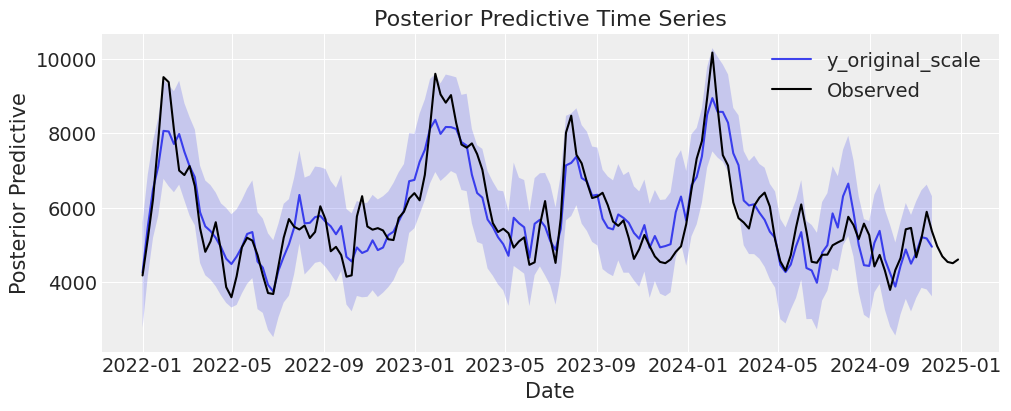

In [ ]:
# actual vs predicted

fig, axes = mmm.plot.posterior_predictive(var=["y_original_scale"], hdi_prob=0.94)
sns.lineplot(
    data=data, x="date", y="y", color="black", label="Observed", ax=axes[0][0]
);

In [27]:
# Generate posterior predictive samples
posterior_preds = mmm.sample_posterior_predictive(X_train, random_seed=rng)

Output()

In [29]:
# Calculate metrics for all posterior samples
results = compute_summary_metrics(
    y_true=y_train,
    y_pred=posterior_preds.y_original_scale.to_numpy(),
    metrics_to_calculate=[
        "r_squared",
        "rmse",
        "nrmse",
        "mae",
        "nmae",
        "mape",
    ],
    hdi_prob=hdi_prob,
)

# Print results in a formatted way
for metric, stats in results.items():
    print(f"\n{metric.upper()}:")
    for stat, value in stats.items():
        print(f"  {stat}: {value:.4f}")


R_SQUARED:
  mean: 0.6859
  median: 0.6870
  std: 0.0300
  min: 0.5886
  max: 0.7778
  94%_hdi_lower: 0.6255
  94%_hdi_upper: 0.7385

RMSE:
  mean: 927.2943
  median: 926.1363
  std: 57.0638
  min: 770.0253
  max: 1159.0731
  94%_hdi_lower: 818.8433
  94%_hdi_upper: 1031.9562

NRMSE:
  mean: 0.1412
  median: 0.1410
  std: 0.0087
  min: 0.1173
  max: 0.1765
  94%_hdi_lower: 0.1247
  94%_hdi_upper: 0.1572

MAE:
  mean: 741.5757
  median: 740.6355
  std: 48.1939
  min: 607.1264
  max: 938.0418
  94%_hdi_lower: 647.6975
  94%_hdi_upper: 828.8909

NMAE:
  mean: 0.1129
  median: 0.1128
  std: 0.0073
  min: 0.0925
  max: 0.1429
  94%_hdi_lower: 0.0986
  94%_hdi_upper: 0.1262

MAPE:
  mean: 0.1318
  median: 0.1315
  std: 0.0088
  min: 0.1065
  max: 0.1706
  94%_hdi_lower: 0.1155
  94%_hdi_upper: 0.1485


AttributeError: module 'arviz' has no attribute 'plot_hdi'

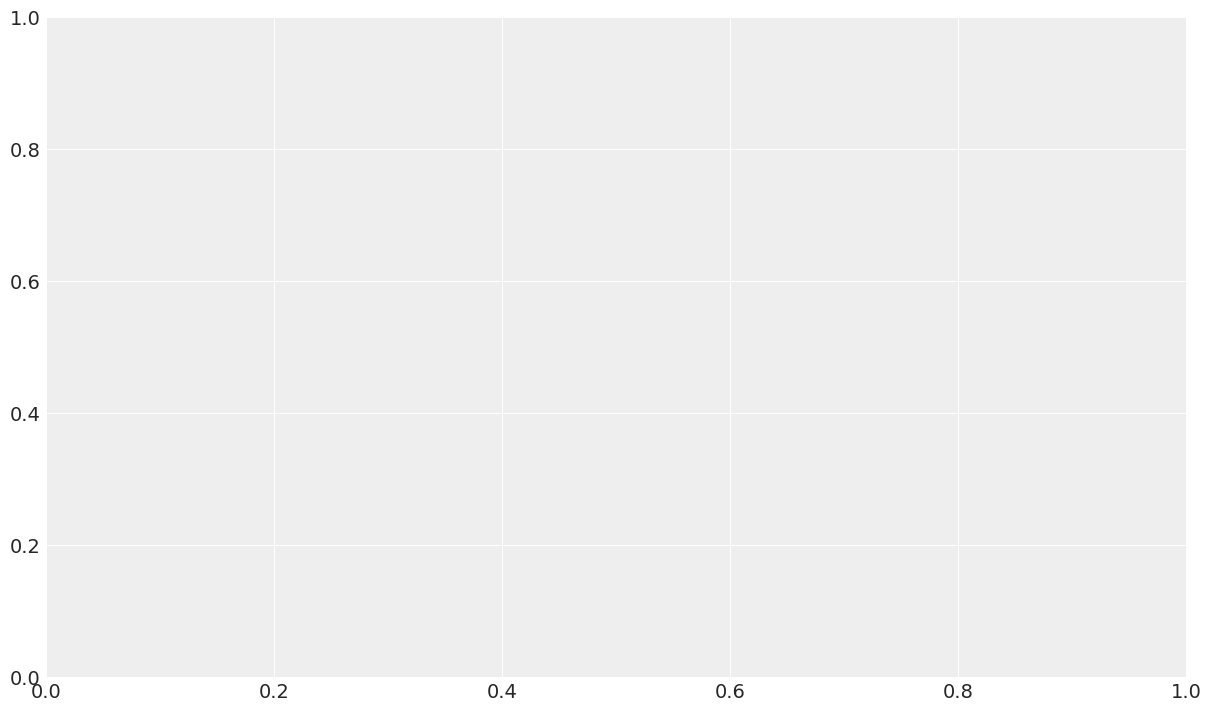

In [30]:
# Compute errors: true - predicted

errors = (
    y_train.to_numpy()[np.newaxis, np.newaxis, :] - mmm.idata["posterior"]["y_original_scale"]
)

fig, ax = plt.subplots()
for i, hdi_prob in enumerate([0.94, 0.5]):
    az.plot_hdi(
        x=mmm.model.coords["date"],
        y=errors,
        color="C3",
        smooth=False,
        hdi_prob=hdi_prob,
        fill_kwargs={"alpha": 0.3 + i * 0.1, "label": f"{hdi_prob:.0%} HDI"},
        ax=ax,
    )
sns.lineplot(
    x=mmm.model.coords["date"],
    y=errors.mean(dim=("chain", "draw")),
    color="C3",
    label="Posterior Mean",
    ax=ax,
)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.legend()
ax.set(xlabel="date", ylabel="error")
ax.set_title("Posterior Predictive Errors", fontsize=16, fontweight="bold");

## OOS - train

In [ ]:
X_test.head()

,date,Google Display Cost,Google Branded Paid Search Cost,TV Cost,Google Generic Paid Search Cost,Influencers Cost,Meta Cost,YouTube Cost,Dates_School_Holidays,Competitors Promotion,Promotion,t
152,2024-11-30,0.00000,7165.05,4493.548387,12189.5496,0.0,8304.3210,5474.952,0,14.0,14.0,152
153,2024-12-07,11540.80486,9050.39,4493.548387,12280.3232,0.0,10914.7344,5063.688,0,14.0,14.0,153
154,2024-12-14,0.00000,10562.53,4493.548387,10912.9704,0.0,7810.7166,5115.096,0,14.0,14.0,154
155,2024-12-21,0.00000,10368.47,4493.548387,10296.3168,0.0,13449.8622,4618.152,0,14.0,14.0,155
156,2024-12-28,0.00000,11768.68,8873.666667,8738.2240,0.0,15752.1036,4112.640,0,14.0,14.0,156


In [ ]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 152 to 156
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   date                             5 non-null      datetime64[ns]
 1   Google Display Cost              5 non-null      float64       
 2   Google Branded Paid Search Cost  5 non-null      float64       
 3   TV Cost                          5 non-null      float64       
 4   Google Generic Paid Search Cost  5 non-null      float64       
 5   Influencers Cost                 5 non-null      float64       
 6   Meta Cost                        5 non-null      float64       
 7   YouTube Cost                     5 non-null      float64       
 8   Dates_School_Holidays            5 non-null      int64         
 9   Competitors Promotion            5 non-null      float64       
 10  Promotion                        5 non-null      float64      

In [ ]:
# forecast 'y' based on model coefficients and test dates

y_out_of_sample = mmm.sample_posterior_predictive(X_test, extend_idata=False)
y_out_of_sample

Output()

<xarray.Dataset> Size: 208kB
Dimensions:           (date: 5, sample: 2000)
Coordinates:
  * date              (date) datetime64[ns] 40B 2024-11-30 ... 2024-12-28
  * sample            (sample) object 16kB MultiIndex
  * chain             (sample) int64 16kB 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1
  * draw              (sample) int64 16kB 0 1 2 3 4 5 ... 995 996 997 998 999
Data variables:
    y                 (date, sample) float64 80kB 0.4419 0.4708 ... 0.596 0.5276
    y_original_scale  (date, sample) float64 80kB 4.491e+03 ... 5.362e+03
Attributes:
    created_at:                 2026-06-04T10:54:56.476048+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.28.5

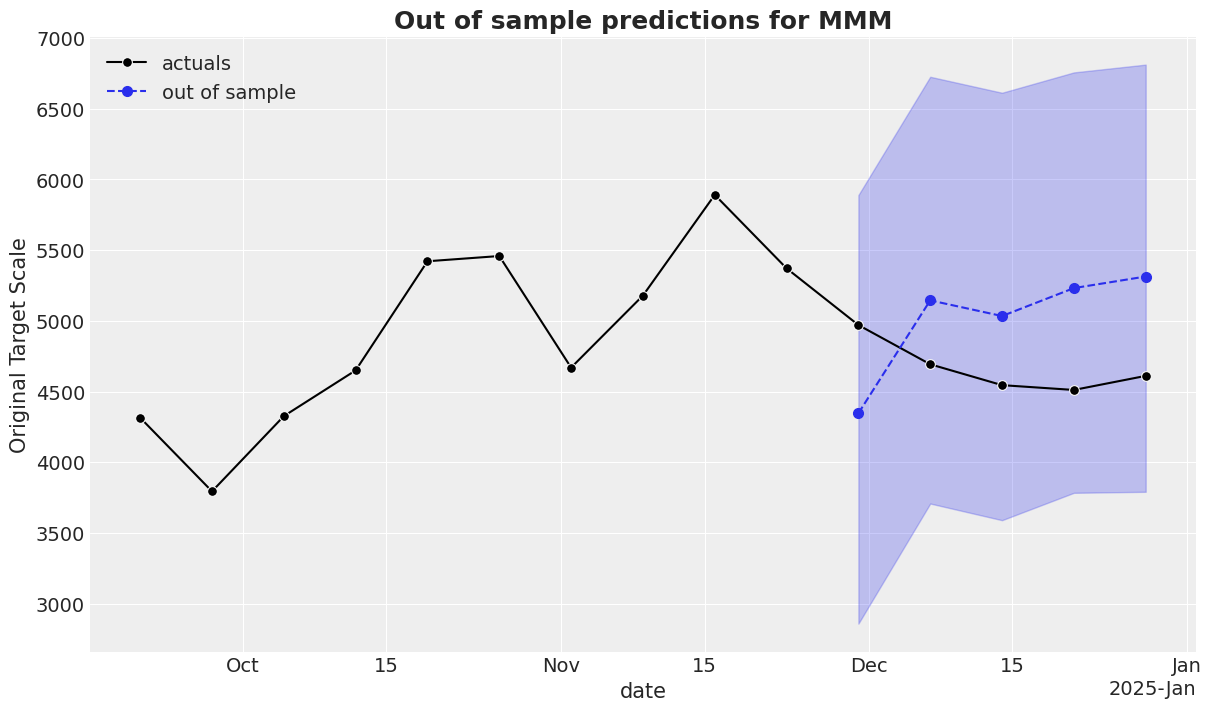

In [ ]:
# plot forecasted 'y' alongside actual 'y'

def plot_in_sample(X, y, ax, n_points: int = 15):
    sns.lineplot(
        x=X["date"][-n_points:],
        y=y[-n_points:],
        marker="o",
        markersize=7,
        color="black",
        label="actuals",
        ax=ax,
    )
    return ax


def plot_out_of_sample(X_out_of_sample, y_out_of_sample, ax, color, label):
    y_out_original_scale = (
        y_out_of_sample["y_original_scale"].unstack().transpose(..., "date")
    )
    az.plot_hdi(
        X_out_of_sample["date"].dt.to_pydatetime(),
        y_out_original_scale,
        smooth=False,
        fill_kwargs={"alpha": 0.25, "color": color},
        ax=ax,
    )

    mean = y_out_original_scale.mean(dim=("chain", "draw"))
    mean.plot(ax=ax, marker="o", markersize=7, label=label, color=color, linestyle="--")
    ax.set(ylabel="Original Target Scale")
    ax.set_title("Out of sample predictions for MMM", fontsize=18, fontweight="bold")
    return ax


_, ax = plt.subplots()
plot_in_sample(X, y, ax=ax)
plot_out_of_sample(
    X_test, y_out_of_sample, ax=ax, label="out of sample", color="C0"
)
ax.legend(loc="upper left");

In [ ]:
# forecast 'y' including adstock carryover

y_out_of_sample_with_adstock = mmm.sample_posterior_predictive(
    X_test, extend_idata=False, include_last_observations=True
)

Output()

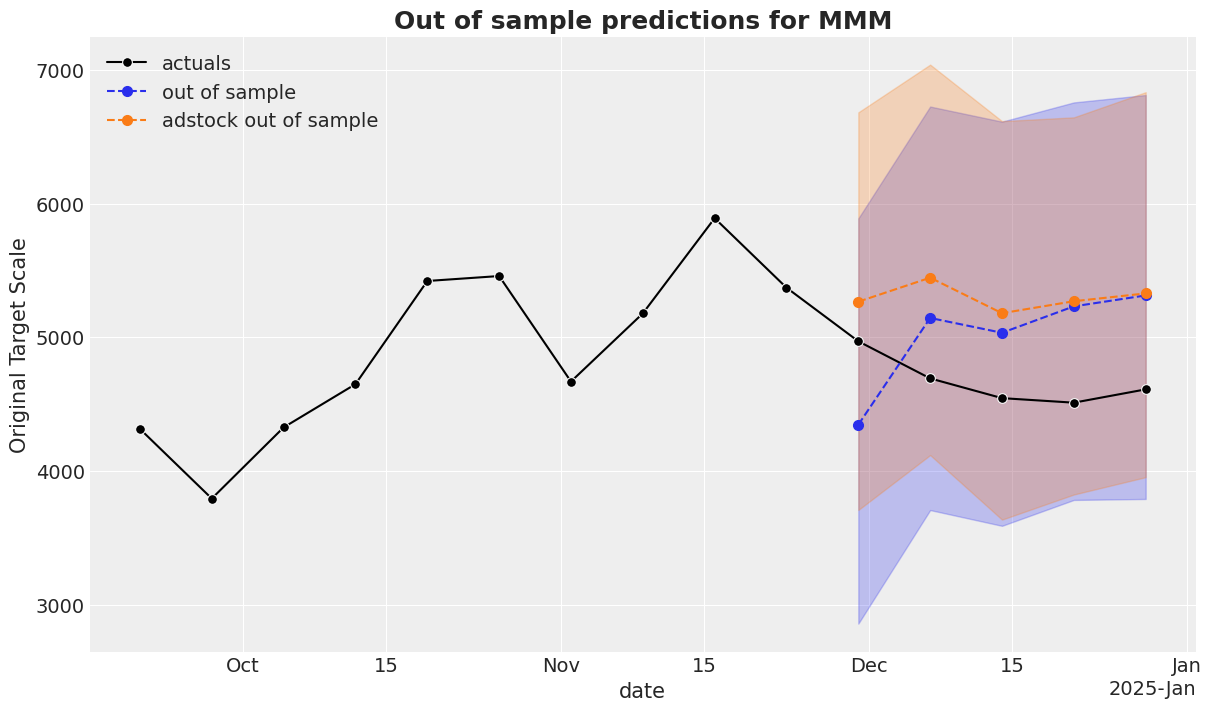

In [ ]:
# plot new 'y' with previous prediction and actual 'y'

_, ax = plt.subplots()
plot_in_sample(X, y, ax=ax)
plot_out_of_sample(
    X_test, y_out_of_sample, ax=ax, label="out of sample", color="C0"
)
plot_out_of_sample(
    X_test,
    y_out_of_sample_with_adstock,
    ax=ax,
    label="adstock out of sample",
    color="C1",
)
ax.legend();

#Full model

##Model specification

In [31]:
my_sampler_config = {"progressbar": True}

/usr/local/lib/python3.13/dist-packages/pymc_extras/prior.py:851: UserWarning: Implicit conversion of array-like parameter sigma to DataArray with dims ('channel',). Use DataArray with explicit dims to avoid this warning
  return _param_value_with_dims(param, value, dims=self.dims)


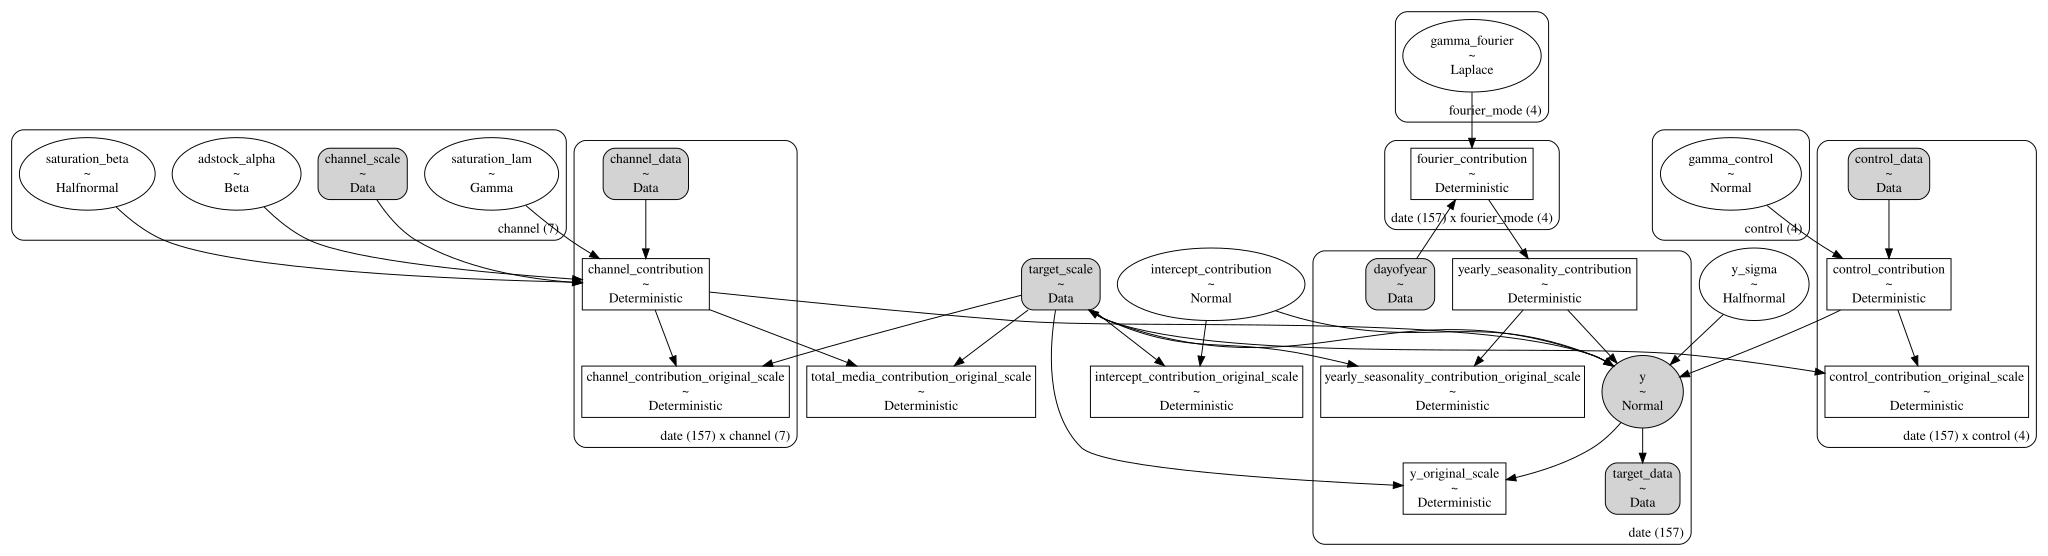

In [32]:
# specify the model based on your model configuration

mmm = MMM(
    model_config=my_model_config,
    sampler_config=my_sampler_config,
    date_column="date", # no need to change
    target_column="y", # no need to change
    adstock=GeometricAdstock(l_max=8),  # change to specific adstock type/ config if required
    saturation=LogisticSaturation(),  #change to 'saturation' if custom priors specified, "LogSaturation" if a Log-Log model is needed
    channel_columns=channels, # no need to change
    control_columns=controls, # no need to change
    yearly_seasonality=2,
    link="identity", #Components add to 𝑦 - change to "log" if components multiply to 𝑦,
)

# Build the model and add contribution variables in original scale
mmm.build_model(X, y)
mmm.add_original_scale_contribution_variable(
    var=[
        "channel_contribution",
        "control_contribution",
        "intercept_contribution",
        "yearly_seasonality_contribution",
        "y",
    ]
)

pm.model_to_graphviz(mmm.model)

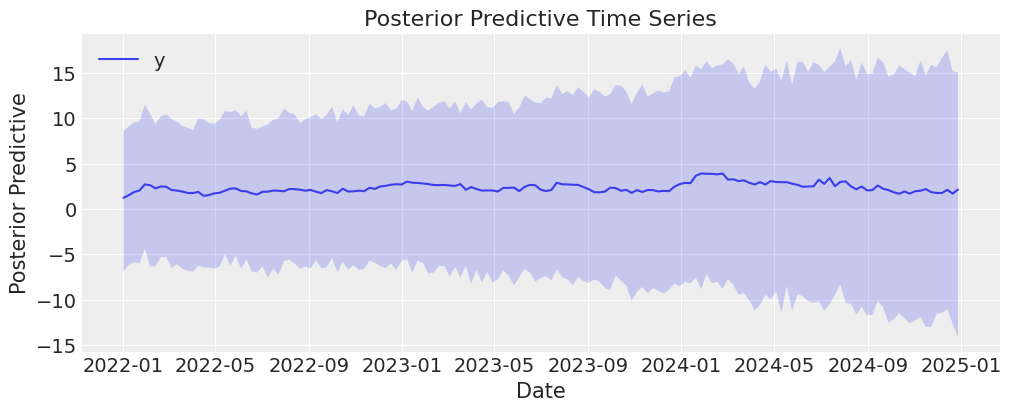

In [33]:
# Generate prior predictive samples

mmm.sample_prior_predictive(X, y, samples=2_000)
fig, axes = mmm.plot.prior_predictive()

AttributeError: module 'arviz' has no attribute 'plot_hdi'

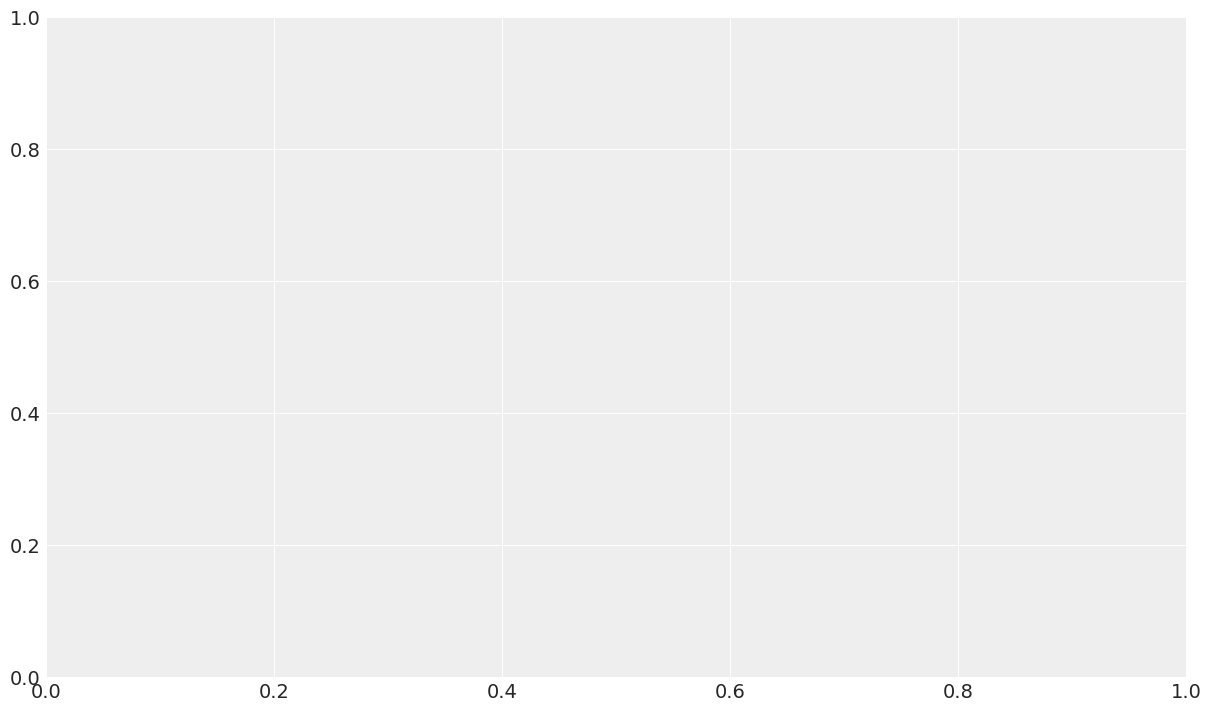

In [34]:
# Prior predictive checks in the original scale

fig, ax = plt.subplots()
for i, hdi_prob in enumerate([0.94, 0.5]):
    az.plot_hdi(
        x=mmm.model.coords["date"],
        y=mmm.idata["prior"]["y_original_scale"].unstack().transpose(..., "date"),
        smooth=False,
        color="C0",
        hdi_prob=hdi_prob,
        fill_kwargs={"alpha": 0.3 + i * 0.1, "label": f"{hdi_prob:.0%} HDI"},
        ax=ax,
    )
sns.lineplot(data=data, x="date", y="y", color="black", label="Observed", ax=ax)
ax.legend(loc="upper left")
ax.set(xlabel="date", ylabel="y")
ax.set_title("Prior Predictive Checks", fontsize=18, fontweight="bold");

##Model fitting

In [37]:
%%time

mmm.fit(
    X=X,
    y=y,
    chains=2, #change to 4 for accuracy
    tune=1_000, #change to 1_500 for accuracy
    draws=1_000,
    target_accept=0.85, #change to 0.9+ for accuracy
    random_seed=rng,
)

KeyboardInterrupt: 

In [ ]:
# save the model

mmm.save(fname="model")

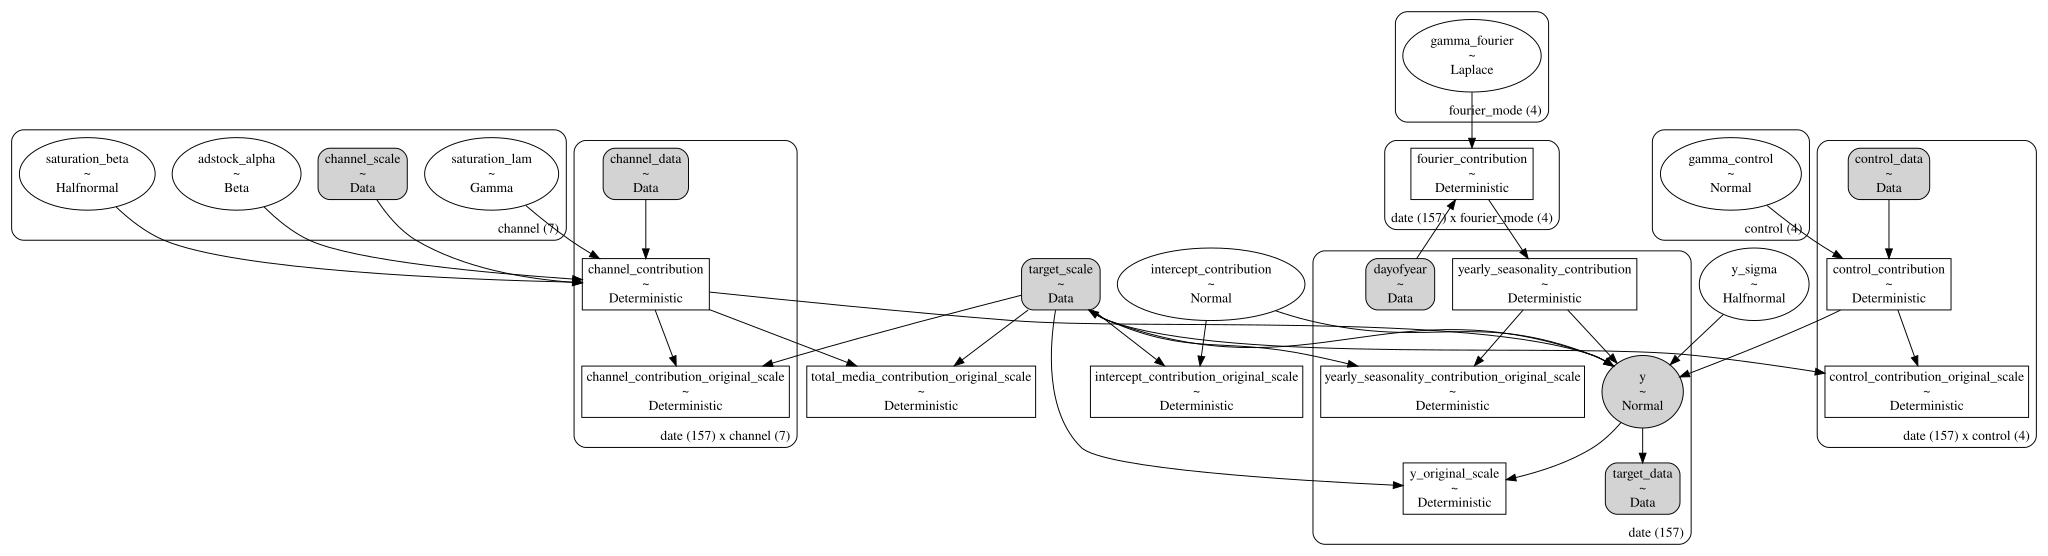

In [36]:
# view the model structure

mmm.graphviz()

In [ ]:
# load the model (if needed)

mmm.load(fname="model")

##Model diagnostics

In [38]:
mmm.table()

                                 Variable  Expression                                  Dimensions                  
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                          channel_scale =  Data                                        channel[7]                  
                           target_scale =  Data                                                                    
                           channel_data =  Data                                        date[157] × channel[7]      
                            target_data =  Data                                        date[157]                   
                           control_data =  Data                                        date[157] × control[4]      
                              dayofyear =  Data                                        date[157]                   
                                                                                                                   
                 intercept_contribution ~  Normal(0.5, 0.2)                                                        
                          adstock_alpha ~  Beta(1, 3)                                  channel[7]                  
                         saturation_lam ~  Gamma(3, <constant>)                        channel[7]                  
                        saturation_beta ~  HalfNormal(0, <constant>)                   channel[7]                  
                          gamma_control ~  Normal(0, 0.05)                             control[4]                  
                          gamma_fourier ~  Laplace(0, 0.2)                             fourier_mode[4]             
                                y_sigma ~  HalfNormal(0, 6)                                                        
                                                                                       Parameter count = 31        
                                                                                                                   
                   channel_contribution =  f(saturation_beta, saturation_lam,          date[157] × channel[7]      
                                           adstock_alpha)                                                          
                   control_contribution =  f(gamma_control)                            date[157] × control[4]      
                   fourier_contribution =  f(gamma_fourier)                            date[157] × fourier_mode[4] 
        yearly_seasonality_contribution =  f(gamma_fourier)                            date[157]                   
  total_media_contribution_original_scale  f(saturation_beta, saturation_lam,                                      
                                        =  adstock_alpha)                                                          
    channel_contribution_original_scale =  f(saturation_beta, saturation_lam,          date[157] × channel[7]      
                                           adstock_alpha)                                                          
    control_contribution_original_scale =  f(gamma_control)                            date[157] × control[4]      
  intercept_contribution_original_scale =  f(intercept_contribution)                                               
 yearly_seasonality_contribution_origina…  f(gamma_fourier)                            date[157]                   
                                        =                                                                          
                       y_original_scale =  f(y)                                        date[157]                   
                                                                                                                   
                                      y ~  Normal(f(intercept_contribution,            date[157]                   
                                           gamma_control

In [39]:
# Number of diverging samples

mmm.idata["sample_stats"]["diverging"].sum().item()

1

In [40]:
mmm.fit_result

<xarray.Dataset> Size: 73MB
Dimensions:                                         (chain: 2, draw: 1000,
                                                     fourier_mode: 4,
                                                     control: 4, channel: 7,
                                                     date: 157)
Coordinates:
  * chain                                           (chain) int64 16B 0 1
  * draw                                            (draw) int64 8kB 0 1 ... 999
  * fourier_mode                                    (fourier_mode) <U5 80B 's...
  * control                                         (control) <U21 336B 'Date...
  * channel                                         (channel) <U31 868B 'Goog...
  * date                                            (date) datetime64[ns] 1kB ...
Data variables: (12/17)
    y_sigma                                         (chain, draw) float64 16kB ...
    gamma_fourier                                   (chain, draw, fourier_mode) float64 64kB ...
    gamma_control                                   (chain, draw, control) float64 64kB ...
    adstock_alpha                                   (chain, draw, channel) float64 112kB ...
    saturation_lam                                  (chain, draw, channel) float64 112kB ...
    saturation_beta                                 (chain, draw, channel) float64 112kB ...
    ...                                              ...
    channel_contribution_original_scale             (chain, draw, date, channel) float64 18MB ...
    total_media_contribution_original_scale         (chain, draw) float64 16kB ...
    yearly_seasonality_contribution                 (chain, draw, date) float64 3MB ...
    fourier_contribution                            (chain, draw, date, fourier_mode) float64 10MB ...
    control_contribution                            (chain, draw, date, control) float64 10MB ...
    channel_contribution                            (chain, draw, date, channel) float64 18MB ...
Attributes:
    created_at:                 2026-09-22T14:12:26.382787+00:00
    creation_library:           ArviZ
    creation_library_version:   1.3.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  6.2.0
    sample_dims:                ['chain', 'draw']
    sampling_time:              76.83466649055481
    tuning_steps:               1000
    pymc_marketing_version:     1.1.0

In [41]:
# summary of the trace

az.summary(
    data=mmm.fit_result,
    var_names=[
        "adstock_alpha",
        "gamma_control",
        "gamma_fourier",
        "intercept_contribution",
        "saturation_beta",
        "saturation_lam",
        "y_sigma",
    ],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
adstock_alpha[Google Display Cost],0.212,0.17,0.016,0.54,1615,1037,1.00,0.0033,0.0034
adstock_alpha[Meta Cost],0.39,0.236,0.056,0.8,1511,1450,1.00,0.0062,0.0037
adstock_alpha[Google Generic Paid Search Cost],0.312,0.133,0.094,0.52,1535,1302,1.00,0.0034,0.0025
adstock_alpha[TV Cost],0.58,0.2,0.18,0.83,984,644,1.00,0.0076,0.0056
adstock_alpha[Influencers Cost],0.249,0.186,0.019,0.61,2396,1152,1.00,0.0034,0.0042
adstock_alpha[Google Branded Paid Search Cost],0.244,0.188,0.016,0.6,2238,1014,1.00,0.0037,0.004
adstock_alpha[YouTube Cost],0.125,0.087,0.013,0.28,1763,1026,1.00,0.0017,0.0019
gamma_control[Dates_School_Holidays],0.0096,0.0027,0.0054,0.014,1934,1359,1.00,6.1e-05,6.5e-05
gamma_control[Competitors Promotion],-0.00845,0.00169,-0.011,-0.0057,1255,1245,1.00,4.8e-05,3.7e-05
gamma_control[Promotion],0.00342,0.00123,0.0015,0.0054,1611,1459,1.01,3.1e-05,2.8e-05


In [42]:
# plot the trace - check for good chain mixing

_ = az.plot_trace(
    data=mmm.fit_result,
    var_names=[
        "adstock_alpha",
        "gamma_control",
        "gamma_fourier",
        "intercept_contribution",
        "saturation_beta",
        "saturation_lam",
        "y_sigma",
    ],
    compact=True,
    backend_kwargs={"figsize": (12, 10), "layout": "constrained"},
)
plt.gcf().suptitle("Model Trace", fontsize=18, fontweight="bold");

TypeError: plot_trace() missing 1 required positional argument: 'dt'

In [43]:
mmm.sample_posterior_predictive(X=X, random_seed=rng)

Output()

<xarray.Dataset> Size: 5MB
Dimensions:           (date: 157, sample: 2000)
Coordinates:
  * date              (date) datetime64[ns] 1kB 2022-01-01 ... 2024-12-28
  * sample            (sample) object 16kB MultiIndex
  * chain             (sample) int64 16kB 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1
  * draw              (sample) int64 16kB 0 1 2 3 4 5 ... 995 996 997 998 999
Data variables:
    y                 (date, sample) float64 3MB 0.3922 0.3346 ... 0.4722 0.3968
    y_original_scale  (date, sample) float64 3MB 3.986e+03 ... 4.033e+03
Attributes:
    created_at:                 2026-09-22T14:13:23.179743+00:00
    creation_library:           ArviZ
    creation_library_version:   1.3.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  6.2.0
    sample_dims:                ['sample']

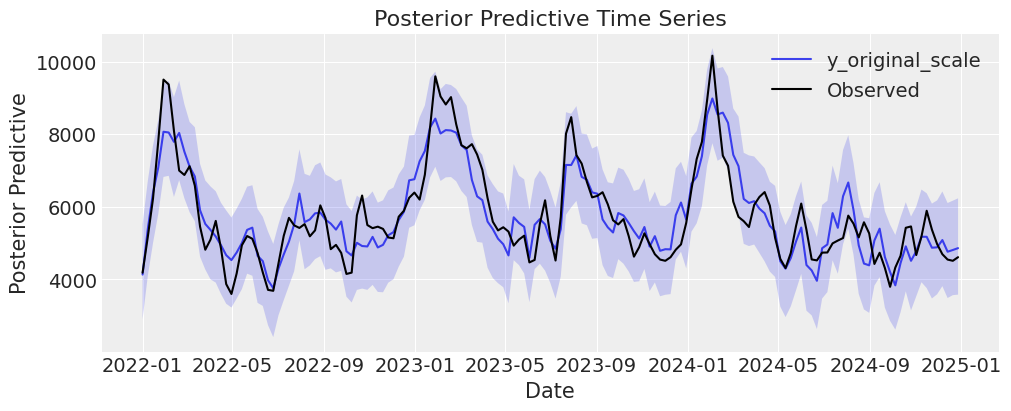

In [44]:
# actual vs predicted

fig, axes = mmm.plot.posterior_predictive(var=["y_original_scale"], hdi_prob=0.94)
sns.lineplot(
    data=data, x="date", y="y", color="black", label="Observed", ax=axes[0][0]
);

In [45]:
posterior_preds = mmm.sample_posterior_predictive(X, random_seed=rng)

Output()

In [46]:
# Calculate metrics for all posterior samples
results = compute_summary_metrics(
    y_true=y,
    y_pred=posterior_preds.y_original_scale.to_numpy(),
    metrics_to_calculate=[
        "r_squared",
        "rmse",
        "nrmse",
        "mae",
        "nmae",
        "mape",
    ],
    hdi_prob=hdi_prob,
)

# Print results in a formatted way
for metric, stats in results.items():
    print(f"\n{metric.upper()}:")
    for stat, value in stats.items():
        print(f"  {stat}: {value:.4f}")


R_SQUARED:
  mean: 0.6899
  median: 0.6910
  std: 0.0286
  min: 0.5754
  max: 0.7695
  94%_hdi_lower: 0.6373
  94%_hdi_upper: 0.7428

RMSE:
  mean: 911.6651
  median: 910.2163
  std: 56.1072
  min: 751.7881
  max: 1132.4270
  94%_hdi_lower: 804.4149
  94%_hdi_upper: 1014.7443

NRMSE:
  mean: 0.1388
  median: 0.1386
  std: 0.0085
  min: 0.1145
  max: 0.1725
  94%_hdi_lower: 0.1225
  94%_hdi_upper: 0.1545

MAE:
  mean: 728.8798
  median: 728.8908
  std: 47.1439
  min: 604.1315
  max: 923.2798
  94%_hdi_lower: 638.6418
  94%_hdi_upper: 813.8328

NMAE:
  mean: 0.1110
  median: 0.1110
  std: 0.0072
  min: 0.0920
  max: 0.1406
  94%_hdi_lower: 0.0973
  94%_hdi_upper: 0.1239

MAPE:
  mean: 0.1300
  median: 0.1299
  std: 0.0087
  min: 0.1066
  max: 0.1632
  94%_hdi_lower: 0.1145
  94%_hdi_upper: 0.1469


AttributeError: module 'arviz' has no attribute 'plot_hdi'

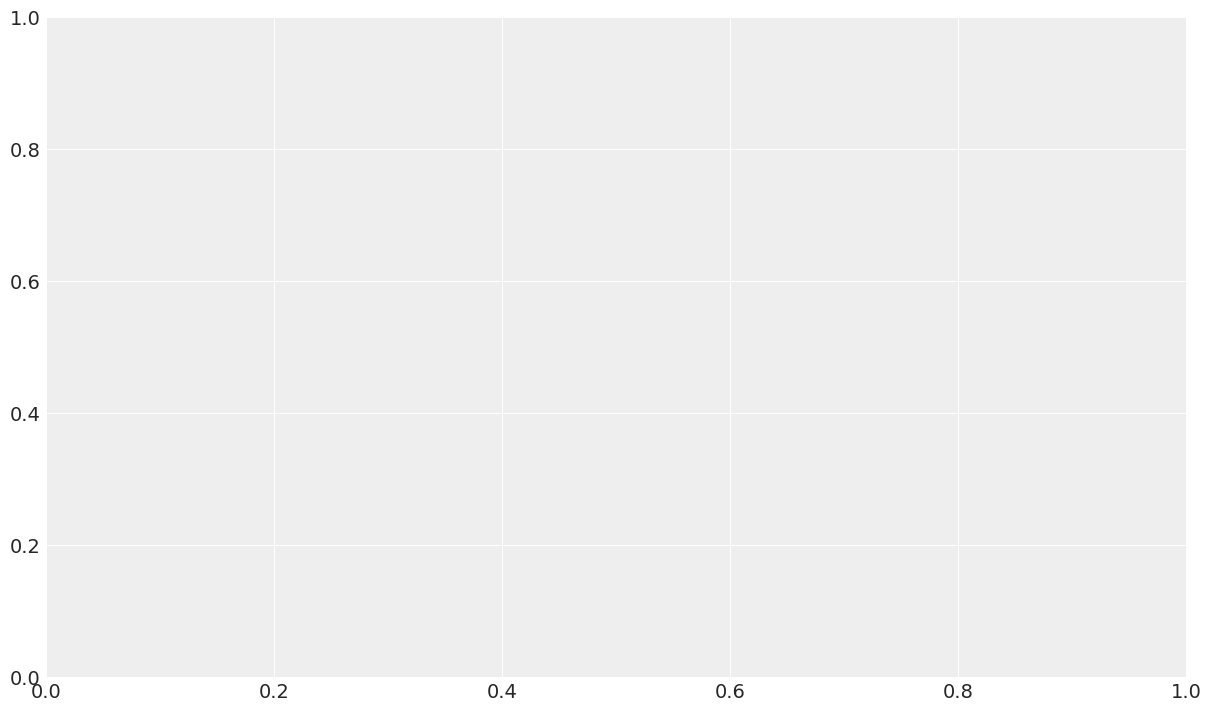

In [47]:
# Compute errors: true - predicted

errors = (
    y.to_numpy()[np.newaxis, np.newaxis, :] - mmm.idata["posterior"]["y_original_scale"]
)

fig, ax = plt.subplots()
for i, hdi_prob in enumerate([0.94, 0.5]):
    az.plot_hdi(
        x=mmm.model.coords["date"],
        y=errors,
        color="C3",
        smooth=False,
        hdi_prob=hdi_prob,
        fill_kwargs={"alpha": 0.3 + i * 0.1, "label": f"{hdi_prob:.0%} HDI"},
        ax=ax,
    )
sns.lineplot(
    x=mmm.model.coords["date"],
    y=errors.mean(dim=("chain", "draw")),
    color="C3",
    label="Posterior Mean",
    ax=ax,
)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.legend()
ax.set(xlabel="date", ylabel="error")
ax.set_title("Posterior Predictive Errors", fontsize=16, fontweight="bold");

##Model insights

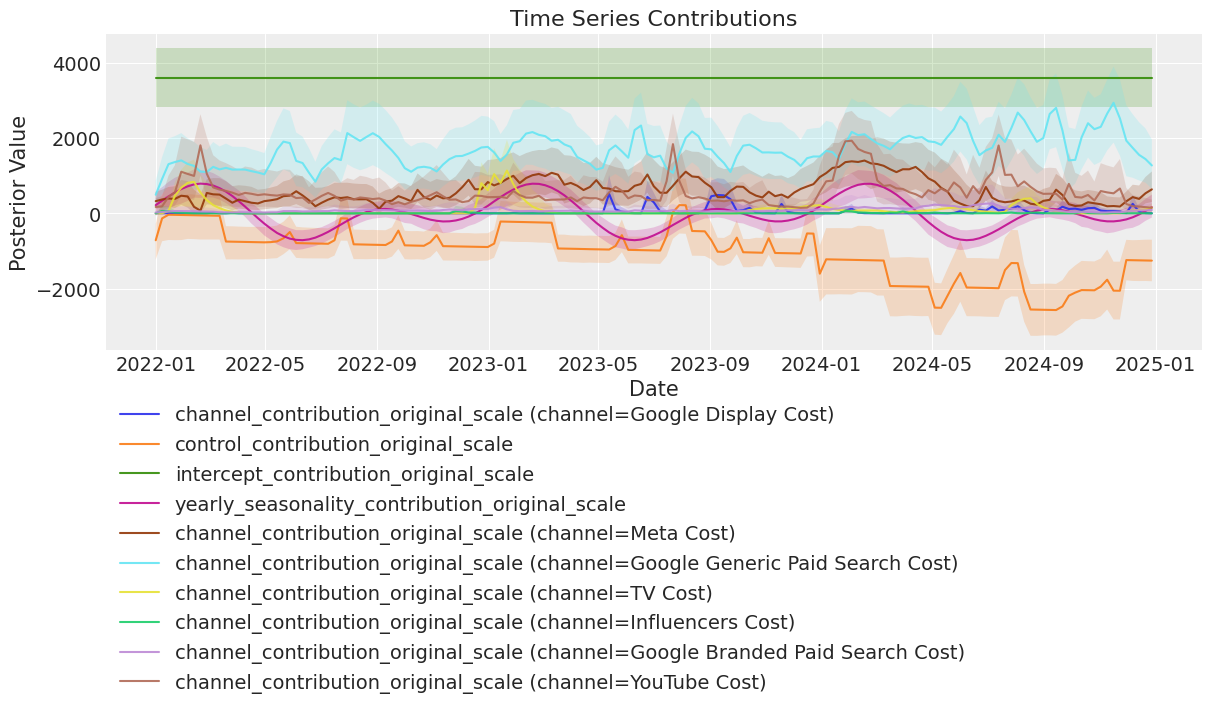

In [ ]:
# Component contributions (original scale)

fig, ax = mmm.plot.contributions_over_time(
    var=[
        "channel_contribution_original_scale",
        "control_contribution_original_scale",
        "intercept_contribution_original_scale",
        "yearly_seasonality_contribution_original_scale",
    ],
    dims={"channel": channels},
    combine_dims=True,
    hdi_prob=0.94,
    figsize=(12, 7),
)


legend = ax[0, 0].get_legend()
legend.set_bbox_to_anchor((0.8, -0.12))

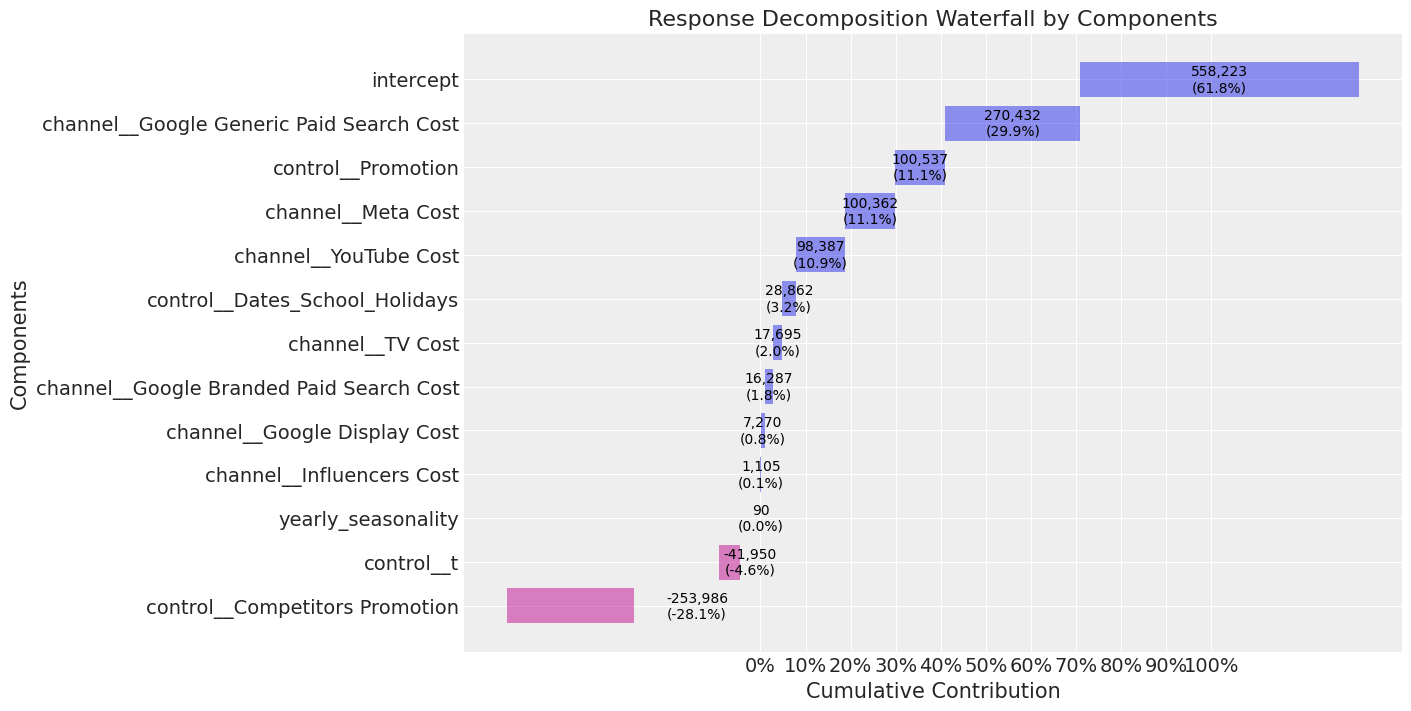

In [ ]:
#waterfall plot (whole modelling period)

mmm.plot.waterfall_components_decomposition();

In [ ]:
# weekly trend for mean contribution

mmm.compute_mean_contributions_over_time()

,date,Google Display Cost,Meta Cost,Google Generic Paid Search Cost,TV Cost,Influencers Cost,Google Branded Paid Search Cost,YouTube Cost,Dates_School_Holidays,Competitors Promotion,Promotion,t,yearly_seasonality,intercept
0,2022-01-01,0.127624,333.953550,526.508078,0.000000,0.000000,27.754867,201.527747,0.000000,-1199.781311,475.328634,0.000000,229.106249,3555.558817
1,2022-01-08,2.283338,384.098298,956.768899,0.000000,77.592854,44.522811,222.775119,581.116079,-1199.781311,475.328634,-3.425603,342.878780,3555.558817
2,2022-01-15,0.455426,410.546193,1350.656611,66.179105,66.527613,61.203566,509.107520,677.968759,-1199.781311,475.328634,-6.851206,454.751197,3555.558817
3,2022-01-22,5.926001,410.562250,1403.616894,474.096212,29.788529,74.357800,643.790229,677.968759,-1199.781311,475.328634,-10.276809,558.634588,3555.558817
4,2022-01-29,1.132594,494.268458,1448.563052,678.121426,24.860790,75.155069,1177.343767,677.968759,-1199.781311,475.328634,-13.702412,648.636723,3555.558817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,2024-11-30,11.370793,337.853864,1971.221332,47.166486,2.773826,62.960867,303.072394,0.000000,-1199.781311,475.328634,-520.691665,-160.135209,3555.558817
153,2024-12-07,262.617144,452.343948,1779.825373,72.916017,0.941436,81.745832,228.151342,0.000000,-1199.781311,475.328634,-524.117268,-101.023019,3555.558817
154,2024-12-14,52.063026,414.870246,1598.881021,89.194921,0.408428,96.533191,217.073268,0.000000,-1199.781311,475.328634,-527.542871,-22.834944,3555.558817
155,2024-12-21,15.878315,556.814184,1485.584114,100.167389,0.200728,98.663809,196.786863,0.000000,-1199.781311,475.328634,-530.968474,71.348316,3555.558817


##Media insights

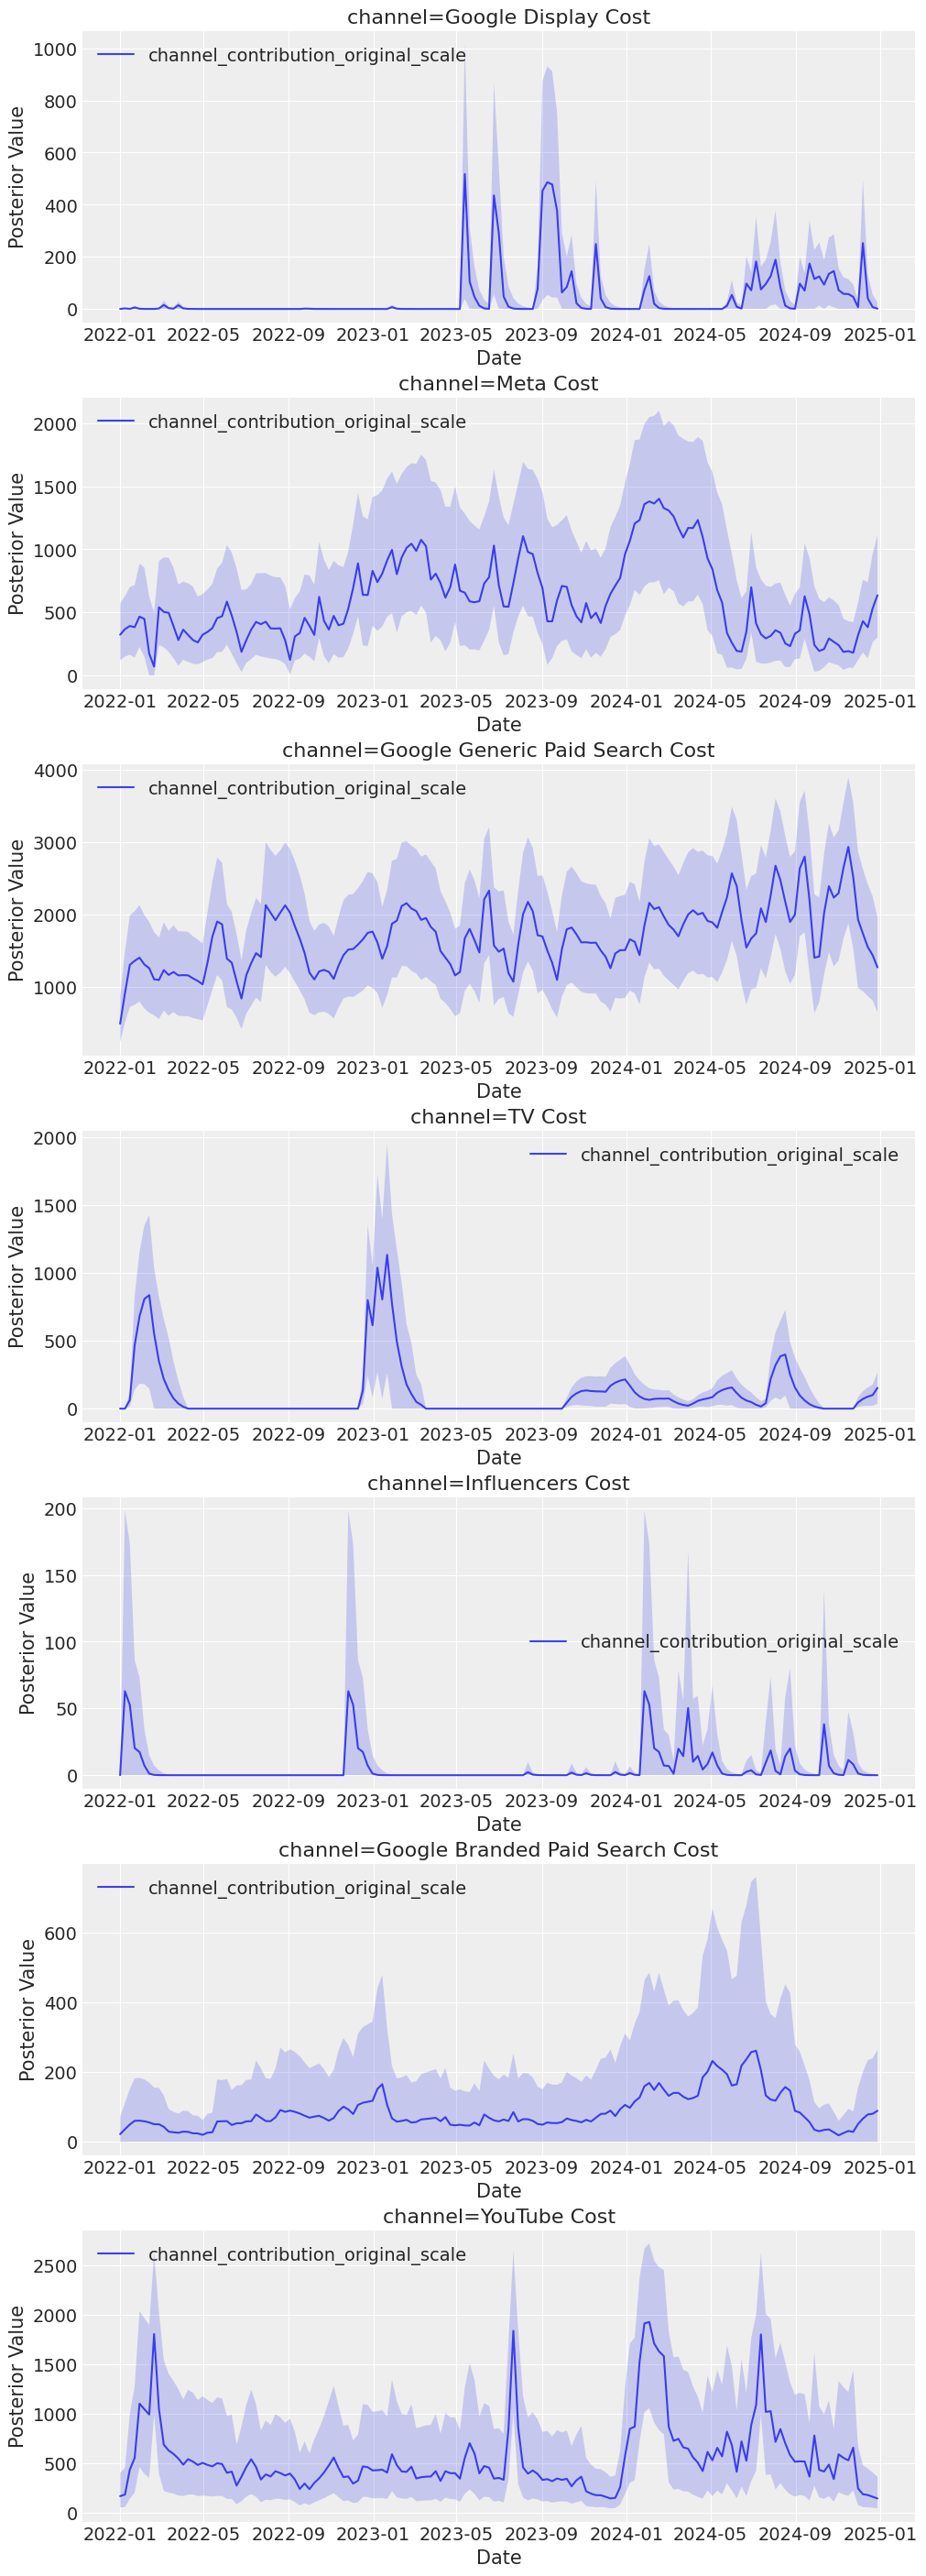

In [ ]:
# Component contributions (original scale)

mmm.plot.contributions_over_time(
    var=["channel_contribution_original_scale"],
    hdi_prob=0.94,
);

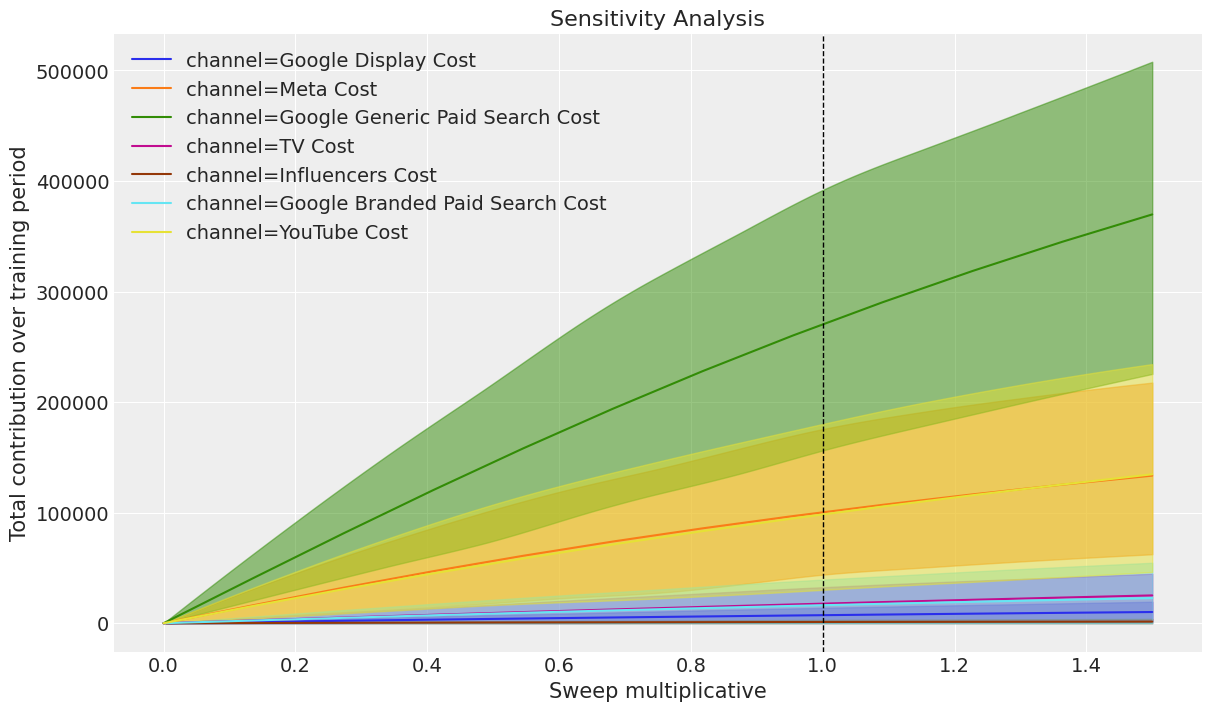

In [ ]:
# Run sensitivity analysis i.e. marginal analysis sweep, based on % of actual spend (1 = 100% i.e. total actual spend)

sweeps = np.linspace(0, 1.5, 12)
mmm.sensitivity.run_sweep(
    sweep_values=sweeps,
    var_input="channel_data",
    var_names="channel_contribution_original_scale",
    extend_idata=True,
)

# Plot sensitivity analysis
ax = mmm.plot.sensitivity_analysis(
    xlabel="Sweep multiplicative",
    ylabel="Total contribution over training period",
    hue_dim="channel",
    x_sweep_axis="relative",
)
ax.axvline(1.0, color="black", linestyle="--", linewidth=1);

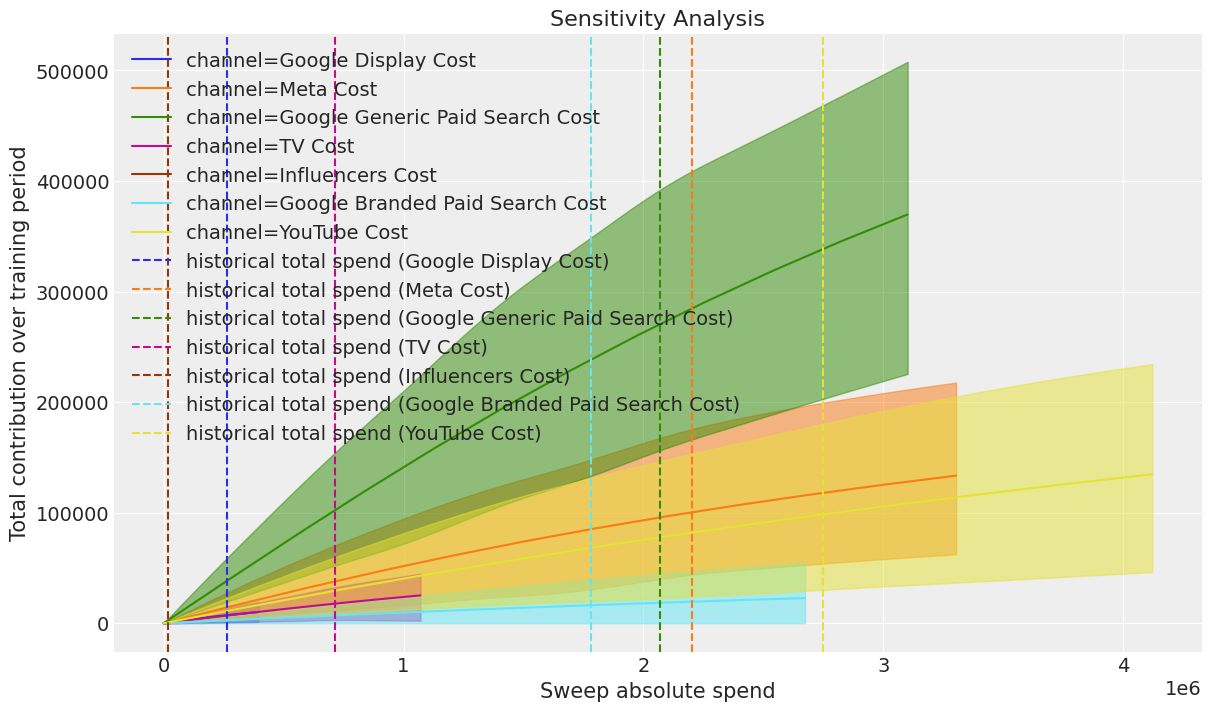

In [ ]:
# Sensitivity analysis with absolute x-axis - dotted line = actual spend values

ax = mmm.plot.sensitivity_analysis(
    xlabel="Sweep absolute spend",
    ylabel="Total contribution over training period",
    hue_dim="channel",
    x_sweep_axis="absolute",
)

for i, channel in enumerate(channels):
    ax.axvline(
        X[channel].sum(),
        color=f"C{i}",
        linestyle="--",
        label=f"historical total spend ({channel})",
    )

ax.legend(loc="upper left");

## Forecasting

In [ ]:
# extrapolate data for future dates - replace with dataframe based on actual values, if needed

last_date = X["date"].max()

# New dates starting from last in dataset
n_new = 5
new_dates = pd.date_range(start=last_date, periods=1 + n_new, freq="W-MON")[1:]

X_out_of_sample = pd.DataFrame(
    {
        "date": new_dates,
    }
)

# Same channel spends as last day
for channel in channels:
    X_out_of_sample[channel] = X[channel].iloc[-1]

# Other features
X_out_of_sample["Dates_School_Holidays"] = 0
X_out_of_sample["Competitors Promotion"] = X["Competitors Promotion"].iloc[-1]
X_out_of_sample["Promotion"] = X["Promotion"].iloc[-1]

X_out_of_sample["t"] = range(len(X), len(X) + n_new)

X_out_of_sample

,date,Google Display Cost,Meta Cost,Google Generic Paid Search Cost,TV Cost,Influencers Cost,Google Branded Paid Search Cost,YouTube Cost,Dates_School_Holidays,Competitors Promotion,Promotion,t
0,2025-01-06,0.0,15752.1036,8738.224,8873.666667,0.0,11768.68,4112.64,0,14.0,14.0,157
1,2025-01-13,0.0,15752.1036,8738.224,8873.666667,0.0,11768.68,4112.64,0,14.0,14.0,158
2,2025-01-20,0.0,15752.1036,8738.224,8873.666667,0.0,11768.68,4112.64,0,14.0,14.0,159
3,2025-01-27,0.0,15752.1036,8738.224,8873.666667,0.0,11768.68,4112.64,0,14.0,14.0,160
4,2025-02-03,0.0,15752.1036,8738.224,8873.666667,0.0,11768.68,4112.64,0,14.0,14.0,161


In [ ]:
X_out_of_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   date                             5 non-null      datetime64[ns]
 1   Google Display Cost              5 non-null      float64       
 2   Meta Cost                        5 non-null      float64       
 3   Google Generic Paid Search Cost  5 non-null      float64       
 4   TV Cost                          5 non-null      float64       
 5   Influencers Cost                 5 non-null      float64       
 6   Google Branded Paid Search Cost  5 non-null      float64       
 7   YouTube Cost                     5 non-null      float64       
 8   Dates_School_Holidays            5 non-null      int64         
 9   Competitors Promotion            5 non-null      float64       
 10  Promotion                        5 non-null      float64       
 1

In [ ]:
# forecast 'y' based on model coefficients and extrapolated dates

y_out_of_sample = mmm.sample_posterior_predictive(X_out_of_sample, extend_idata=False)
y_out_of_sample

Output()

<xarray.Dataset> Size: 208kB
Dimensions:           (date: 5, sample: 2000)
Coordinates:
  * date              (date) datetime64[ns] 40B 2025-01-06 ... 2025-02-03
  * sample            (sample) object 16kB MultiIndex
  * chain             (sample) int64 16kB 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1
  * draw              (sample) int64 16kB 0 1 2 3 4 5 ... 995 996 997 998 999
Data variables:
    y                 (date, sample) float64 80kB 0.4411 0.3275 ... 0.5046
    y_original_scale  (date, sample) float64 80kB 4.483e+03 ... 5.128e+03
Attributes:
    created_at:                 2026-06-08T13:37:04.845976+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.28.5

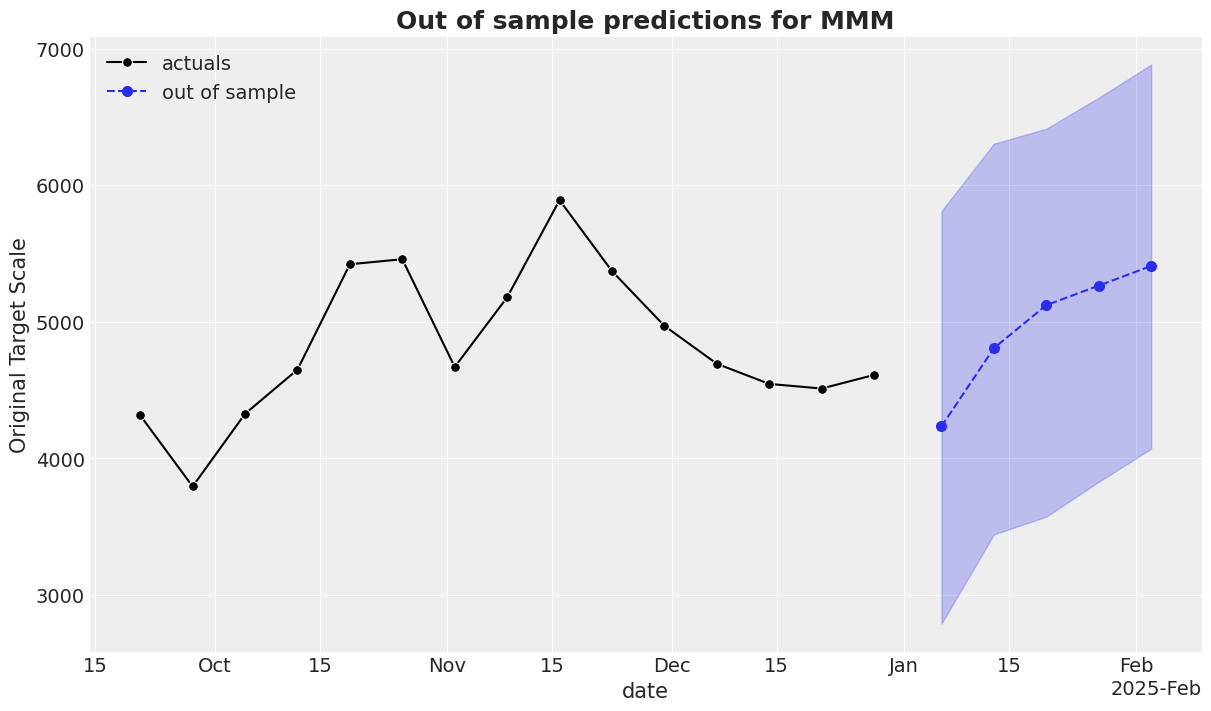

In [ ]:
# plot forecasted 'y' alongside actual 'y'

def plot_in_sample(X, y, ax, n_points: int = 15):
    sns.lineplot(
        x=X["date"][-n_points:],
        y=y[-n_points:],
        marker="o",
        markersize=7,
        color="black",
        label="actuals",
        ax=ax,
    )
    return ax


def plot_out_of_sample(X_out_of_sample, y_out_of_sample, ax, color, label):
    y_out_original_scale = (
        y_out_of_sample["y_original_scale"].unstack().transpose(..., "date")
    )
    az.plot_hdi(
        X_out_of_sample["date"].dt.to_pydatetime(),
        y_out_original_scale,
        smooth=False,
        fill_kwargs={"alpha": 0.25, "color": color},
        ax=ax,
    )

    mean = y_out_original_scale.mean(dim=("chain", "draw"))
    mean.plot(ax=ax, marker="o", markersize=7, label=label, color=color, linestyle="--")
    ax.set(ylabel="Original Target Scale")
    ax.set_title("Out of sample predictions for MMM", fontsize=18, fontweight="bold")
    return ax


_, ax = plt.subplots()
plot_in_sample(X, y, ax=ax)
plot_out_of_sample(
    X_out_of_sample, y_out_of_sample, ax=ax, label="out of sample", color="C0"
)
ax.legend(loc="upper left");

In [ ]:
# forecast 'y' including adstock carryover

y_out_of_sample_with_adstock = mmm.sample_posterior_predictive(
    X_out_of_sample, extend_idata=False, include_last_observations=True
)

Output()

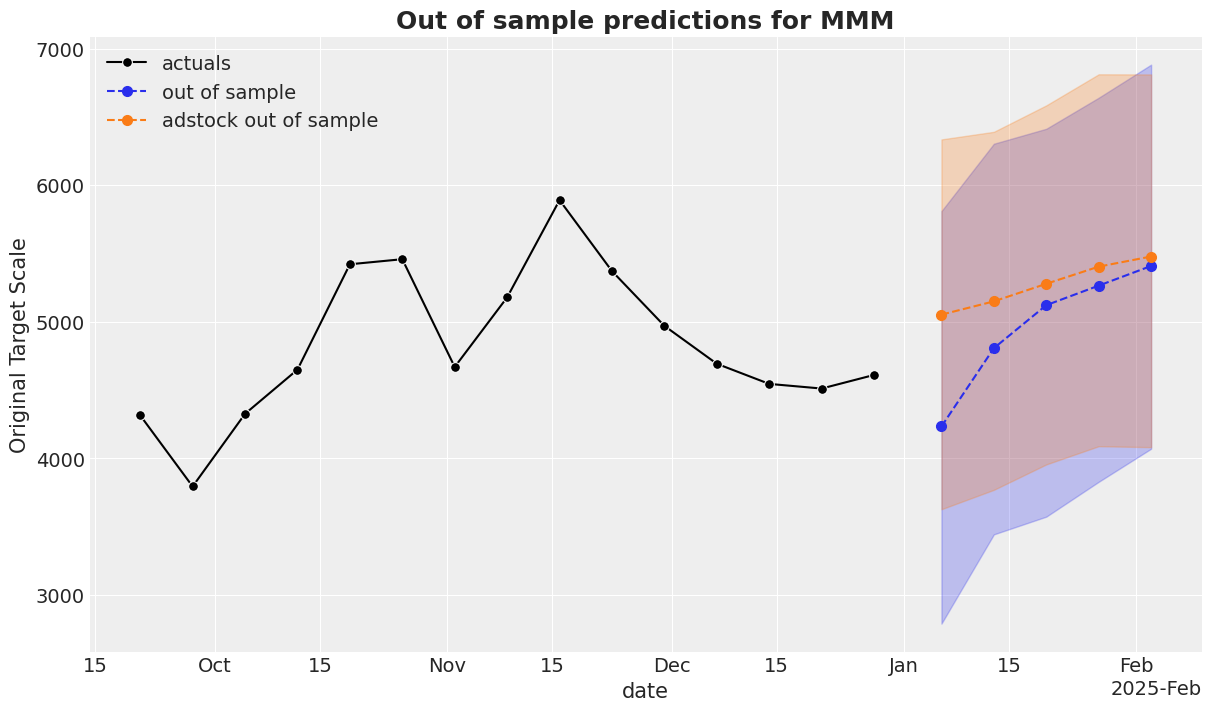

In [ ]:
# plot new 'y' with previous prediction and actual 'y'

_, ax = plt.subplots()
plot_in_sample(X, y, ax=ax)
plot_out_of_sample(
    X_out_of_sample, y_out_of_sample, ax=ax, label="out of sample", color="C0"
)
plot_out_of_sample(
    X_out_of_sample,
    y_out_of_sample_with_adstock,
    ax=ax,
    label="adstock out of sample",
    color="C1",
)
ax.legend();